# 1D CNN — Two-Hand Dynamic Gesture Recognition

Clean, single-path pipeline for training **several 1D-CNN architecture variants** on the glove data and exporting a comparison PDF.

**Pipeline stages**
1. Imports
2. Training and Model Configuration
3. Sensor Column Selection
4. Load Training Data
5. Preprocessing
6. Train/Test Split
7. Augmentation Helpers
8. Cross Validation
9. Final Retrain
10. Training Curves
11. Hold-out Test Evaluation
12. Batch Test

Only the CNN-on-sequences path is supported here. Engineered-feature/MLP variants have been removed to keep the notebook readable.


## 1. Imports


In [ ]:
import os
import re
import glob
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal as scipy_signal
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split as _val_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Permute
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D, Activation, Input, LSTM, Bidirectional
from tensorflow.keras.models import Sequential


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)


# ── Determinism: cover every random-number source so runs are reproducible ─
# Without this, Python's `random`, NumPy's legacy global RNG, the OS hash seed,
# and (on GPU) cuDNN non-determinism all introduce variance between runs even
# when you set the same RANDOM_STATE.
def set_global_determinism(seed):
    """Make a TF/Keras notebook bit-for-bit reproducible across runs.

    Costs a small amount of speed (5–15%) for full op determinism; the trade
    is well worth it during model development and ablation studies.
    """
    import random as _random
    import numpy as _np
    os.environ['PYTHONHASHSEED']        = str(seed)
    os.environ['TF_DETERMINISTIC_OPS']   = '1'   # TF op-level determinism flag
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'   # cuDNN-specific (GPU only, harmless on CPU)
    _random.seed(seed)
    _np.random.seed(seed)
    import tensorflow as _tf
    _tf.random.set_seed(seed)
    # set_random_seed seeds Python random + NumPy + TF in one call; idempotent
    _tf.keras.utils.set_random_seed(seed)
    # The strongest knob: forces deterministic kernels for every TF op (TF>=2.9)
    try:
        _tf.config.experimental.enable_op_determinism()
    except Exception:
        pass  # older TF, env-var flags above are best-effort


# Run determinism setup BEFORE any other code touches a random number generator.
set_global_determinism(42)
print('Imports OK · global determinism enabled (seed=42).')


Imports OK · global determinism enabled (seed=42).


## 2. Configuration

All knobs in one place. Edit only this cell to run different experiments.


In [ ]:



def build_baseline(seq_len, n_chan, n_classes):
    """Original architecture from the notebook."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='Baseline')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_shallow(seq_len, n_chan, n_classes):
    """Single Conv block — fewer params, faster to train."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        # Permute((2, 1)),
        Conv1D(32, kernel_size=1, strides=1, padding='valid', activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='Shallow')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_deep(seq_len, n_chan, n_classes):
    """Three Conv blocks — more representational depth."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, activation='relu'),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(n_classes, activation='softmax'),
    ], name='Deep')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_bn_gap(seq_len, n_chan, n_classes):
    """BatchNorm + GlobalAveragePooling — typically better generalisation, fewer params."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, padding='same'),
        BatchNormalization(), Activation('relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, padding='same'),
        BatchNormalization(), Activation('relu'),
        MaxPooling1D(2),
        Conv1D(128, 3, padding='same'),
        BatchNormalization(), Activation('relu'),
        GlobalAveragePooling1D(),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='BN_GAP')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_wide_kernel(seq_len, n_chan, n_classes):
    """Wider kernels — larger temporal receptive field per layer."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 8, activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 8, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='WideKernel')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_cnn_lstm(seq_len, n_chan, n_classes):
    """CNN feature extractor → LSTM temporal model.

    Two Conv1D blocks pull out local temporal features, then a single LSTM
    consumes the resulting (T', F) sequence and a final Dense head classifies.
    Conv layers use padding='same' so MaxPooling controls the temporal
    downsampling explicitly.
    """
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='CNN_LSTM')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_cnn_bilstm(seq_len, n_chan, n_classes):
    """CNN feature extractor → Bidirectional LSTM temporal model.

    Same Conv front-end as CNN_LSTM but the recurrent stage is bidirectional,
    so each timestep's representation sees both past and future context within
    the trial — useful for gestures where the discriminative motion can sit
    anywhere along the trial.
    """
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='CNN_BiLSTM')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m





# ─────────────────────────────────────────────────────────────────────────────
# Model_I_1D — 1-D adaptation of the published 2-D "Model I" architecture
# Original (in image): Conv2D(3x3,32) → MaxPool(2x2) → BN → Conv2D(2x2,64) →
#                      Conv2D(2x2,64) → MaxPool(2x2) → Flatten → Dense(64) →
#                      Dropout(0.5) → Dense(n_classes)
# 1-D translation per user spec: Conv1 kernel=5 stride=3 (sees 5 time steps,
# advances by 3). Remaining layers keep original kernel sizes and strides=1
# to match the original architecture's information-flow pattern.
# At T=90, output shape evolution: 90 → 29 → 28 → 28 → 27 → 26 → 25 → 1600 → 64 → n
# ─────────────────────────────────────────────────────────────────────────────
def build_model_i_1d(seq_len, n_channels, n_classes):
    """1-D adaptation of 'Model I' from the published architecture.
    
    Faithful 1-D translation: each 2-D conv becomes a Conv1D, spatial axis
    collapses to time, channel axis carries all sensors. Conv1 uses
    kernel_size=5, stride=4 (per the design decision: 'observe 5 rows at a time
    with stride 4'). Subsequent convs use the original kernel_size=2, stride=1.
    """
    m = Sequential([
        Input(shape=(seq_len, n_channels)),
        Permute((2, 1)),
        Conv1D(32, kernel_size=1, strides=1, padding='valid', activation='relu'),
        MaxPooling1D(pool_size=4, strides=2),
        BatchNormalization(),
        Conv1D(64, kernel_size=2, strides=1, padding='valid', activation='relu'),
        Conv1D(64, kernel_size=2, strides=1, padding='valid', activation='relu'),
        MaxPooling1D(pool_size=2, strides=1),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(n_classes, activation='softmax'),
    ], name='Model_I_1D')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


# ─────────────────────────────────────────────────────────────────────────────
# Model_II_1D — 1-D adaptation of the published 2-D "Model II" architecture
# Original: Conv2D(32) -> Conv2D(32) -> BN -> MaxPool -> Drop -> LSTM(64,seq)
#           -> Drop -> LSTM(64) -> Drop -> Dense(128) -> BN -> Drop -> Dense(n)
# 1-D translation: same layer stack + ordering. Conv1 kernel=5 stride=3
# (matches Model_I_1D for fair comparison). Conv2 keeps original kernel=3.
# Heavy dropout (0.5) at four points + two BN layers — paper clearly fighting
# overfitting; preserved here since your LOUO setting is similar.
# At T=90: 90 -> 29 -> 27 -> 13 (after pool) -> LSTM sees 13 time steps.
# ─────────────────────────────────────────────────────────────────────────────
def build_model_ii_1d(seq_len, n_channels, n_classes):
    """1-D adaptation of 'Model II' (CNN + stacked LSTM) from the published paper.
    
    Two Conv1D feature-extractor layers + BatchNorm + MaxPool, then a 2-layer
    stacked LSTM classifier with heavy dropout. First LSTM returns full
    sequence; second returns final state only.
    """
    m = Sequential([
        Input(shape=(seq_len, n_channels)),
        Conv1D(32, kernel_size=5, strides=3, padding='valid', activation='relu'),
        Conv1D(32, kernel_size=3, strides=1, padding='valid', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, strides=2),
        Dropout(0.5),
        LSTM(64, return_sequences=True),
        Dropout(0.5),
        LSTM(64, return_sequences=False),
        Dropout(0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(n_classes, activation='softmax'),
    ], name='Model_II_1D')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


In [22]:
BATCH_TEST_ROOT = '/home/jestin/ThesisRepo2/NewTestData/8_Jestin/NewNewDynamic'
TEST_USER = BATCH_TEST_ROOT.split('/')[-2]
print(f'Test user: {TEST_USER}')

Test user: 8_Jestin


In [ ]:
# ── Data locations ───────────────────────────────────────────────────────────
# You can include data from MULTIPLE users / source folders.
#
# Each entry in DATA_PATHS is a folder that DIRECTLY contains gesture-label
# subfolders (e.g. .../Alan/Dynamic, .../Bridgette/Dynamic). All matching label
# folders across these paths are merged by label name, so e.g.
# Alan/Dynamic/Wave and Bridgette/Dynamic/Wave end up in the same "Wave" class.
#
# Tip: comment out a path to exclude that user from training without deleting it.
DATA_PATHS = [
    # '/home/jestin/ThesisRepo2/NewTrainingData/Dynamic',

    '/home/jestin/ThesisRepo2/NewTrainingData/NewNewDynamic',

    # '/home/jestin/ThesisRepo2/NewTestData/user_1/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_2/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_3/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_4/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_5/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_6/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_7/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_8/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_9/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_10/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_11/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_12/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_13/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_14/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_15/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_16/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_17/Dynamic',
    # '/home/jestin/ThesisRepo2/NewTestData/user_18/Dynamic'

]


# Backwards-compat shortcut: set DATA_ROOT to a string and leave DATA_PATHS = None
# (or empty) to use the old single-folder workflow.
DATA_ROOT = None

INCLUDE_LABELS  = None   # None = use every label subfolder found

# INCLUDE_LABELS = [
#     'Double_Lower',
#     # 'Double_Nothing',
#     'Double_Pistol_Recoil',
#     'Double_Raise',
#     'Double_Wiggle',
#     'Double_cmere',
#     'Drum_Roll',
# ]


# ── Sensor selection (per-sensor toggles, laid out as a grid) ───────────────
# Each row is one body segment; each column is one sensor position on that
# segment. Flip True/False to include/exclude individual sensors.
#
#   IMU_mid  / IMU_prox  : the two IMUs on the segment (mid = distal,
#                          prox = proximal). Wrist has only one IMU; put it
#                          in the IMU_mid column.
#   Flex_MCP / Flex_PIP  : the two flex sensors on the finger joint.
#   '.'                  : that sensor doesn't physically exist there.
#
# Notes:
#   - palm has no flex sensors. wrist has no flex sensors and no prox IMU.
#   - palm_mid IMUs exist in the CSV but contain no real sensor data
#     (left as False below — flip to True only if your data has them).
#   - Which channels each enabled IMU contributes (YPR / quat / accel) is
#     controlled by the USE_YPR / USE_QUAT / USE_ACCEL flags below.

ReportPostfix = "Configuration2_shallow"

#                       IMU_mid   IMU_prox    Flex_MCP    Flex_PIP
SENSOR_GRID = {
    'left': {
        'palm':      ( True,      '.',        '.',        '.'      ),
        'thumb':     ( False,      True,        True,       True     ),
        'index':     ( False,      True,        True,       True     ),
        'middle':    ( False,      True,        True,       True     ),
        'ring':      ( False,      True,        True,       True     ),
        'pinky':     ( False,      True,        True,       True     ),
        'wrist':     ( False,      '.',          '.',        '.'      ),
    },
    'right': {
        'palm':      ( True,      '.',        '.',        '.'      ),
        'thumb':     ( False,      True,        True,       True     ),
        'index':     ( False,      True,        True,       True     ),
        'middle':    ( False,      True,        True,       True     ),
        'ring':      ( False,      True,        True,       True     ),
        'pinky':     ( False,      True,        True,       True     ),
        'wrist':     ( False,      '.',          '.',        '.'      ),
    },
}

# Column → (suffix, allowed segments). Cells outside allowed segments must be '.'.
_GRID_COLUMNS = [
    ('mid_imu',  None),                                    # all segments (wrist uses this slot)
    ('prox_imu', None),                                    # all segments except wrist
    ('mcp_flex', {'thumb', 'index', 'middle', 'ring', 'pinky'}),
    ('pip_flex', {'thumb', 'index', 'middle', 'ring', 'pinky'}),
]


def _grid_to_sensors(grid):
    """Flatten SENSOR_GRID into the flat SENSORS dict the column builder
    expects: {sensor_id: bool}. Validates '.' placement strictly."""
    out = {}
    for hand, rows in grid.items():
        for seg, cells in rows.items():
            if len(cells) != len(_GRID_COLUMNS):
                raise ValueError(
                    f"{hand}/{seg}: expected {len(_GRID_COLUMNS)} columns, got {len(cells)}")
            for (suffix, allowed), val in zip(_GRID_COLUMNS, cells):
                # Special-case the wrist single-IMU slot
                if seg == 'wrist':
                    if suffix == 'mid_imu':
                        sid = f'{hand}_wrist_imu'
                    else:
                        if val != '.':
                            raise ValueError(
                                f"{hand}/wrist column {suffix!r} must be '.', got {val!r}")
                        continue
                else:
                    if allowed is not None and seg not in allowed:
                        if val != '.':
                            raise ValueError(
                                f"{hand}/{seg} column {suffix!r} must be '.', got {val!r}")
                        continue
                    sid = f'{hand}_{seg}_{suffix}'
                if val == '.':
                    continue                                # empty cell — sensor not present
                if not isinstance(val, bool):
                    raise ValueError(
                        f"{hand}/{seg}/{suffix}: expected True/False or '.', got {val!r}")
                out[sid] = val
    return out


SENSORS = _grid_to_sensors(SENSOR_GRID)

# ── Legacy coarse selectors (used only when SENSORS is None) ────────────────
# If you set SENSORS = None above, these older coarse toggles are used to
# build the sensor list (preserved for backwards compatibility).
USE_LEFT_HAND  = True
USE_RIGHT_HAND = True
INCLUDE_SEGMENTS = [
    # 'palm_mid',
    # 'palm_prox',
    'thumb', 'index', 'middle', 'ring', 'pinky', 'wrist',
]

# ── IMU channel modalities ──────────────────────────────────────────────────
# For every enabled IMU sensor above, choose which of its channels to include.
# Flex sensors are unaffected by these flags.
USE_YPR        = False    # IMU Euler angles (yaw / pitch / roll, or heading for wrist)
USE_QUAT       = False   # Raw quaternion components (quat_w/x/y/z)
USE_ACCEL      = False    # Linear accelerometer (ax, ay, az)
USE_FLEX       = True    # Master switch: if False, ignore all *_flex entries
                         # in SENSORS regardless of their value.

# ── Preprocessing ────────────────────────────────────────────────────────────
RESAMPLE_TO_N_STEPS    = 90
APPLY_BUTTERWORTH      = True
BUTTERWORTH_CUTOFF_HZ  = 10.0
BUTTERWORTH_ORDER      = 4
SAMPLING_RATE_HZ       = 30.0
# NORMALISATION options:
#   'standard'         - global StandardScaler fit on train (per-feature mean/std). Default.
#   'minmax'           - global MinMaxScaler  fit on train (per-feature 0..1).
#   'per_trial_zscore' - per-trial, per-channel z-score (each trial normalised against its own stats).
#                        Stateless. Removes user-specific DC offsets + amplitude. Use for cross-user generalisation.
#   None               - no scaling.
NORMALISATION          = 'per_trial_zscore'   
                                                                  # 'standard' | 'minmax' | None

# ── Train/test split ─────────────────────────────────────────────────────────
TEST_SIZE             = 0.10
RANDOM_STATE          = 42
STRATIFY_SPLIT        = True

# ── Cross-validation ─────────────────────────────────────────────────────────
RUN_CROSS_VALIDATION  = True
CV_FOLDS              = 7
CV_SHUFFLE            = True

# ── Augmentation (training only, inside each CV fold) ────────────────────────
AUGMENT_TRAINING_DATA          = True
AUGMENTATION_COPIES_PER_SAMPLE = 6
AUGMENTATION_RANDOM_SEED       = 42
AUGMENT_CONFIG = {
    'time_shift':      {'enabled': True,  'apply_prob': 1.0, 'max_shift_steps': 3, 'fill_mode': 'edge'},
    'time_warp':       {'enabled': True,  'apply_prob': 1.0, 'speed_range': (0.95, 1.05)},
    'time_mask':       {'enabled': True,  'apply_prob': 1.0, 'max_masks': 2, 'max_mask_size': 3, 'fill_mode': 'zero'},
    'gaussian_noise':  {'enabled': False,  'apply_prob': 1.0, 'std_ratio': 0.02},
    'amplitude_scale': {'enabled': True,  'apply_prob': 1.0, 'scale_range': (0.95, 1.05)},
    'baseline_offset': {'enabled': True,  'apply_prob': 1.0, 'offset_std_ratio': 0.02},
    'channel_dropout': {'enabled': True,  'apply_prob': 1.0, 'drop_fraction': 0.03, 'fill_mode': 'zero'},
    # Only enable left/right swap if the class label is symmetric under that swap
    'left_right_swap': {'enabled': False, 'apply_prob': 0.5},
}

# ── Training hyperparameters ─────────────────────────────────────────────────
TRAIN_EPOCHS           = 60     # max epochs; EarlyStopping decides when to stop
TRAIN_BATCH_SIZE       = 16
TRAIN_VALIDATION_SPLIT = 0.2    # only used by the final retrain (not by CV)
TRAIN_VERBOSE          = 1

# ── Early stopping ───────────────────────────────────────────────────────────
EARLY_STOPPING_ENABLED          = True
EARLY_STOPPING_MONITOR          = 'val_loss'   # 'val_loss' (min) or 'val_accuracy' (max)
EARLY_STOPPING_PATIENCE         = 4            # epochs with no improvement before stopping
EARLY_STOPPING_MIN_DELTA        = 0.005          # min change to count as improvement
EARLY_STOPPING_RESTORE_BEST     = True         # roll weights back to best-monitor epoch
EARLY_STOPPING_VERBOSE          = 1

# ── Output paths ─────────────────────────────────────────────────────────────
MODEL_OUTPUT_DIR     = Path('/home/jestin/ThesisRepo2/NewReports/NewNewDynamic')
EXPERIMENT_LOG_PATH  = MODEL_OUTPUT_DIR / 'experiment_results.csv'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Resolve active data paths (supports both DATA_PATHS list and legacy DATA_ROOT)
ACTIVE_DATA_PATHS = []
if DATA_PATHS:
    ACTIVE_DATA_PATHS = [p for p in DATA_PATHS if p and not p.strip().startswith('#')]
if not ACTIVE_DATA_PATHS and DATA_ROOT:
    ACTIVE_DATA_PATHS = [DATA_ROOT]

print('Configuration loaded.')
print(f'  Data paths ({len(ACTIVE_DATA_PATHS)}):')
for p in ACTIVE_DATA_PATHS:
    print(f'    - {p}')


Configuration loaded.
  Data paths (1):
    - /home/jestin/ThesisRepo2/NewTrainingData/NewNewDynamic


In [24]:
VARIANTS = [
    # ('Baseline',   'Conv1D(32,k=4)→Pool→Conv1D(64,k=4)→Pool→Flatten→Dense(64)→Dropout(0.3)→Softmax', build_baseline),
    ('Shallow',    'Single Conv block: Conv1D(32,k=5)→Pool→Flatten→Dense(32)→Dropout(0.3)→Softmax',           build_shallow),
    # ('Deep',       'Three Conv blocks: Conv1D(32,4)→Conv1D(64,4)→Conv1D(128,3)→Flatten→Dense(128)→Dropout(0.4)→Softmax', build_deep),
    # ('BN_GAP',     'Conv+BN+ReLU ×3 with GlobalAveragePooling1D head — fewer params, less overfit',                build_bn_gap),
    # ('WideKernel', 'Conv1D(32,k=8)→Pool→Conv1D(64,k=8)→Pool→Flatten→Dense(64)→Dropout(0.3)→Softmax', build_wide_kernel),
    # ('CNN_LSTM',   'Conv1D(32,4)→Pool→Conv1D(64,4)→Pool→Dropout→LSTM(64)→Dense(64)→Dropout→Softmax',           build_cnn_lstm),
    # ('CNN_BiLSTM', 'Conv1D(32,4)→Pool→Conv1D(64,4)→Pool→Dropout→BiLSTM(64)→Dense(64)→Dropout→Softmax',         build_cnn_bilstm),
    # ('CNN2D_Anatomical',        '2-D Conv over (time, anatomy, modality): Conv2D(32,3x3)→Pool→Conv2D(64,3x3)→Pool→Flatten→Dense(64)→Dropout→Softmax', build_cnn2d_anatomical),
    # ('CNN2D_Anatomical_BN_GAP', '2-D Conv + BN + GAP over (time, anatomy, modality) — fewer params, less overfit',                                            build_cnn2d_anatomical_bn_gap),
    # ('Model_I_1D',              '1-D adaptation of published Model I: Conv1D(32,k=5,s=3)→Pool→BN→Conv1D(64,k=2)→Conv1D(64,k=2)→Pool→Flatten→Dense(64)→Drop(0.5)→Softmax', build_model_i_1d),
    # ('Model_II_1D',             '1-D adaptation of published Model II (CNN+LSTM): Conv1D(32,k=5,s=3)→Conv1D(32,k=3)→BN→Pool→Drop→LSTM(64,seq)→Drop→LSTM(64)→Drop→Dense(128)→BN→Drop→Softmax', build_model_ii_1d),
]

# Container populated by the CV / retrain / hold-out / batch-test cells below.
# Each entry: dict with name, description, n_params, cv_results, cv_mean, cv_std,
# history, test_accuracy, test_loss, classification_report, y_pred, batch_df,
# batch_correct, batch_total, batch_accuracy, model, model_path, scaler.
variant_results = []
print(f'Configured {len(VARIANTS)} variants:')
for n, d, _ in VARIANTS:
    print(f'  - {n}: {d}')

Configured 1 variants:
  - Shallow: Single Conv block: Conv1D(32,k=5)→Pool→Flatten→Dense(32)→Dropout(0.3)→Softmax


## 3. Sensor column selection

Build the list of channel names that match the configuration. Two modes:

- **Grid mode** (default): `SENSOR_GRID` lays out per-sensor True/False toggles by hand × segment × position. It flattens into a flat `SENSORS` dict (`{sensor_id: bool}`) and the column builder expands each enabled sensor into the appropriate CSV column names. Modality flags (`USE_YPR / USE_QUAT / USE_ACCEL / USE_FLEX`) still control which channels each active IMU contributes.
- **Legacy mode** (set `SENSORS = None`): falls back to the older `INCLUDE_SEGMENTS` + modality flags for whole-segment on/off control.

`USE_LEFT_HAND` / `USE_RIGHT_HAND` always gate whole hands in both modes.


In [25]:
# ── Build column selector from config ───────────────────────────────────────
SEGMENTS_WITH_FLEX = ['thumb', 'index', 'middle', 'ring', 'pinky']  # palm has no flex
IMU_LOCATIONS = ['mid', 'prox']  # distal phalanx / proximal phalanx


def _imu_channels(prefix, use_ypr, use_quat, use_accel, is_wrist=False):
    """Return the CSV column names contributed by a single IMU sensor."""
    cols = []
    if use_ypr:
        if is_wrist:
            cols += [f'{prefix}_heading', f'{prefix}_pitch', f'{prefix}_roll']
        else:
            cols += [f'{prefix}_yaw', f'{prefix}_pitch', f'{prefix}_roll']
    if use_quat:
        cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                 f'{prefix}_quat_y', f'{prefix}_quat_z']
    if use_accel:
        cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
    return cols


def build_sensor_columns_from_dict(sensors, use_ypr, use_quat, use_accel, use_flex):
    """Expand a SENSORS dict (sensor_id → bool) into CSV column names.

    sensor_id formats:
        {hand}_{segment}_{loc}_imu      e.g. 'left_index_mid_imu'
        {hand}_wrist_imu
        {hand}_{segment}_{joint}_flex   e.g. 'left_index_mcp_flex'
    """
    cols = []
    for sensor_id, enabled in sensors.items():
        if not enabled:
            continue

        if sensor_id.endswith('_imu'):
            base = sensor_id[:-4]          # strip '_imu'
            is_wrist = base.endswith('_wrist')
            cols += _imu_channels(base, use_ypr, use_quat, use_accel, is_wrist=is_wrist)

        elif sensor_id.endswith('_flex'):
            if not use_flex:
                continue                    # master flex switch
            # The flex column name IS the sensor id (e.g. 'left_index_mcp_flex')
            cols.append(sensor_id)

        else:
            print(f"  WARNING: unrecognised sensor id '{sensor_id}' — skipping.")
    return cols


def build_sensor_columns_legacy(hands, segments, use_ypr, use_quat, use_accel, use_flex):
    """Old coarse builder (kept for SENSORS=None fallback)."""
    seg_map = {
        'palm_mid':  'palm', 'palm_prox': 'palm',
        'thumb': 'thumb', 'index': 'index', 'middle': 'middle',
        'ring':  'ring',  'pinky': 'pinky', 'wrist': 'wrist',
    }
    resolved_segs = list(dict.fromkeys([seg_map[s] for s in segments]))

    cols = []
    for hand in hands:
        for seg in resolved_segs:
            if seg == 'wrist':
                cols += _imu_channels(f'{hand}_wrist', use_ypr, use_quat, use_accel, is_wrist=True)
            else:
                for loc in IMU_LOCATIONS:
                    cols += _imu_channels(f'{hand}_{seg}_{loc}', use_ypr, use_quat, use_accel)
                if use_flex and seg in SEGMENTS_WITH_FLEX:
                    cols += [f'{hand}_{seg}_mcp_flex', f'{hand}_{seg}_pip_flex']
    return cols


# ── Resolve the active sensor column list ───────────────────────────────────
resolved_hands = [h for h, on in [('left', USE_LEFT_HAND), ('right', USE_RIGHT_HAND)] if on]

if 'SENSORS' in globals() and SENSORS is not None:
    # Filter SENSORS by enabled hands so USE_LEFT_HAND / USE_RIGHT_HAND still gate
    _filtered_sensors = {
        sid: on for sid, on in SENSORS.items()
        if any(sid.startswith(f'{h}_') for h in resolved_hands)
    }
    SENSOR_COLS = build_sensor_columns_from_dict(
        sensors  = _filtered_sensors,
        use_ypr  = USE_YPR,
        use_quat = USE_QUAT,
        use_accel= USE_ACCEL,
        use_flex = USE_FLEX,
    )
    _enabled_ids = [k for k, v in _filtered_sensors.items() if v]
    print(f'Sensor selection mode: SENSORS dict (from SENSOR_GRID)')
    print(f'Selected {len(SENSOR_COLS)} sensor columns from {len(_enabled_ids)} enabled sensors.')
else:
    SENSOR_COLS = build_sensor_columns_legacy(
        hands    = resolved_hands,
        segments = INCLUDE_SEGMENTS,
        use_ypr  = USE_YPR,
        use_quat = USE_QUAT,
        use_accel= USE_ACCEL,
        use_flex = USE_FLEX,
    )
    print(f'Sensor selection mode: legacy coarse toggles')
    print(f'Selected {len(SENSOR_COLS)} sensor columns.')

# Drop any accidental duplicates while preserving order
SENSOR_COLS = list(dict.fromkeys(SENSOR_COLS))

print('First 10:', SENSOR_COLS[:10])
print('Last  10:', SENSOR_COLS[-10:])


Sensor selection mode: SENSORS dict (from SENSOR_GRID)
Selected 20 sensor columns from 32 enabled sensors.
First 10: ['left_thumb_mcp_flex', 'left_thumb_pip_flex', 'left_index_mcp_flex', 'left_index_pip_flex', 'left_middle_mcp_flex', 'left_middle_pip_flex', 'left_ring_mcp_flex', 'left_ring_pip_flex', 'left_pinky_mcp_flex', 'left_pinky_pip_flex']
Last  10: ['right_thumb_mcp_flex', 'right_thumb_pip_flex', 'right_index_mcp_flex', 'right_index_pip_flex', 'right_middle_mcp_flex', 'right_middle_pip_flex', 'right_ring_mcp_flex', 'right_ring_pip_flex', 'right_pinky_mcp_flex', 'right_pinky_pip_flex']


## 4. Load training data

Walk the label subfolders under `DATA_ROOT` and read each CSV as a `(T, C)` array of the selected sensor channels.


In [26]:
def load_dataset(data_paths, include_labels, sensor_cols):
    """
    Load all CSVs from gesture-label subfolders found inside each path in
    `data_paths`. Trials from the same label across different source folders
    are merged into a single class.

    Returns:
        trials      : list of np.ndarray (per-trial sensor matrices)
        labels      : list of class label strings
        class_names : sorted list of unique class labels
        source_info : list of source label-folder paths per trial (parallel to trials)
    """
    if isinstance(data_paths, str):
        data_paths = [data_paths]
    if not data_paths:
        raise ValueError('No data paths provided. Set DATA_PATHS or DATA_ROOT.')

    resolved_paths = []
    for p in data_paths:
        p_exp = os.path.expanduser(p)
        if not os.path.isdir(p_exp):
            raise FileNotFoundError(
                f"Data path not found: {p_exp!r}\n"
                "Update DATA_PATHS in the Configuration cell."
            )
        resolved_paths.append(p_exp)

    SKIP = {'PDF', 'sdb', 'idk'}
    label_to_folders = {}   # label -> list of full folder paths
    for root in resolved_paths:
        for d in sorted(os.listdir(root)):
            full = os.path.join(root, d)
            if not os.path.isdir(full) or d in SKIP:
                continue
            label_to_folders.setdefault(d, []).append(full)

    if include_labels is not None:
        label_to_folders = {k: v for k, v in label_to_folders.items()
                            if k in include_labels}
    if not label_to_folders:
        raise ValueError('No label folders found. Check DATA_PATHS and INCLUDE_LABELS.')

    label_names = sorted(label_to_folders.keys())
    print(f'Found {len(label_names)} gesture classes across {len(resolved_paths)} source folder(s):')

    trials, labels, source_info = [], [], []
    for label in label_names:
        folders = label_to_folders[label]
        per_source_counts = []
        for folder in folders:
            csv_files = sorted(glob.glob(os.path.join(folder, '*.csv')))
            per_source_counts.append((folder, len(csv_files)))
            for fpath in csv_files:
                try:
                    df = pd.read_csv(fpath)
                    available = [c for c in sensor_cols if c in df.columns]
                    if not available:
                        print(f'    WARNING: no matching sensor columns in {os.path.basename(fpath)}')
                        continue
                    trials.append(df[available].values.astype(np.float32))
                    labels.append(label)
                    source_info.append(folder)
                except Exception as e:
                    print(f'    ERROR loading {os.path.basename(fpath)}: {e}')
        total = sum(c for _, c in per_source_counts)
        extra = ''
        if len(per_source_counts) > 1:
            extra = ' from ' + ', '.join(
                f"{os.path.basename(os.path.dirname(fp))}({n})"
                for fp, n in per_source_counts
            )
        print(f'  [{label}]  →  {total} files{extra}')

    print(f'\nTotal trials loaded: {len(trials)}')
    return trials, labels, label_names, source_info


trials_raw, labels_raw, class_names, source_info = load_dataset(
    ACTIVE_DATA_PATHS, INCLUDE_LABELS, SENSOR_COLS
)

print('\nClass distribution:')
for cls, cnt in sorted(Counter(labels_raw).items()):
    print(f'  {cls}: {cnt} trials')

# Per-source-folder distribution
print('\nTrials per source folder:')
for src, cnt in sorted(Counter(source_info).items()):
    tag = os.sep.join(src.split(os.sep)[-3:])
    print(f'  {tag}: {cnt} trials')


Found 6 gesture classes across 1 source folder(s):
  [Double_ClosedHand_Flip_OpenHand]  →  120 files
  [Double_FingerTips]  →  120 files
  [Double_Okay_Ring_Middle_Pinky]  →  120 files
  [Double_OpenHand_Flip_ClosedHand]  →  120 files
  [Double_OpenHand_LPunch_R_Punch]  →  120 files
  [Double_Snap]  →  120 files

Total trials loaded: 720

Class distribution:
  Double_ClosedHand_Flip_OpenHand: 120 trials
  Double_FingerTips: 120 trials
  Double_Okay_Ring_Middle_Pinky: 120 trials
  Double_OpenHand_Flip_ClosedHand: 120 trials
  Double_OpenHand_LPunch_R_Punch: 120 trials
  Double_Snap: 120 trials

Trials per source folder:
  NewTrainingData/NewNewDynamic/Double_ClosedHand_Flip_OpenHand: 120 trials
  NewTrainingData/NewNewDynamic/Double_FingerTips: 120 trials
  NewTrainingData/NewNewDynamic/Double_Okay_Ring_Middle_Pinky: 120 trials
  NewTrainingData/NewNewDynamic/Double_OpenHand_Flip_ClosedHand: 120 trials
  NewTrainingData/NewNewDynamic/Double_OpenHand_LPunch_R_Punch: 120 trials
  NewTrain

## 5. Preprocessing

1. Resample every trial to a fixed length so the CNN gets a constant input shape.
2. Optional zero-phase Butterworth low-pass filter to smooth high-frequency noise.


In [27]:
def resample_trial(trial, n_steps):
    """Linear resample (T, C) → (n_steps, C)."""
    T, C = trial.shape
    if T == n_steps:
        return trial.astype(np.float32, copy=False)
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, n_steps)
    out = np.zeros((n_steps, C), dtype=np.float32)
    for c in range(C):
        out[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return out


def apply_butterworth(trials, cutoff, order, fs):
    """Zero-phase low-pass filter applied per channel."""
    nyq = fs / 2.0
    norm_cutoff = cutoff / nyq
    if norm_cutoff >= 1.0:
        print(f'  WARNING: cutoff {cutoff} Hz >= Nyquist {nyq} Hz — skipping filter.')
        return trials
    b, a = scipy_signal.butter(order, norm_cutoff, btype='low', analog=False)
    return [scipy_signal.filtfilt(b, a, t, axis=0).astype(np.float32) for t in trials]


# Resample
if RESAMPLE_TO_N_STEPS is not None:
    trials_resampled = [resample_trial(t, RESAMPLE_TO_N_STEPS) for t in trials_raw]
    print(f'Resampled all trials to {RESAMPLE_TO_N_STEPS} time steps.')
else:
    trials_resampled = trials_raw

# Filter
if APPLY_BUTTERWORTH:
    trials_filtered = apply_butterworth(trials_resampled, BUTTERWORTH_CUTOFF_HZ,
                                        BUTTERWORTH_ORDER, SAMPLING_RATE_HZ)
    print(f'Butterworth low-pass: cutoff={BUTTERWORTH_CUTOFF_HZ} Hz, order={BUTTERWORTH_ORDER}.')
else:
    trials_filtered = trials_resampled
    print('Butterworth filter skipped.')

sequence_length, n_channels = trials_filtered[0].shape
print(f'Trial shape: ({sequence_length}, {n_channels})  (time_steps × channels)')


Resampled all trials to 90 time steps.
Butterworth low-pass: cutoff=10.0 Hz, order=4.
Trial shape: (90, 20)  (time_steps × channels)


## 6. Build X, y and the train/test split

We stack all trials into a single `(N, T, C)` tensor, encode labels, then carve off a stratified hold-out test set. The hold-out set is **never** seen during training, augmentation, or scaler fitting.


In [28]:
X = np.stack(trials_filtered, axis=0).astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

le = LabelEncoder()
y = le.fit_transform(labels_raw)
n_classes = len(le.classes_)
print(f'X shape: {X.shape}    y shape: {y.shape}    n_classes: {n_classes}')
print('Label mapping:', dict(zip(le.classes_, range(n_classes))))

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y if STRATIFY_SPLIT and n_classes > 1 else None,
)
print(f'Train pool: {X_train_pool.shape}    Hold-out test: {X_test.shape}')


X shape: (720, 90, 20)    y shape: (720,)    n_classes: 6
Label mapping: {np.str_('Double_ClosedHand_Flip_OpenHand'): 0, np.str_('Double_FingerTips'): 1, np.str_('Double_Okay_Ring_Middle_Pinky'): 2, np.str_('Double_OpenHand_Flip_ClosedHand'): 3, np.str_('Double_OpenHand_LPunch_R_Punch'): 4, np.str_('Double_Snap'): 5}
Train pool: (648, 90, 20)    Hold-out test: (72, 90, 20)


## 7. Augmentation helpers

Each augmentation operates on a single `(T, C)` trial and is applied probabilistically per `AUGMENT_CONFIG`. `augment_training_set` produces `copies_per_sample` augmented variants per original trial and concatenates them with the originals.

Augmentation is applied **inside** each CV fold's training split — the fold's validation split is left untouched, just like the hold-out test set.


In [29]:
def _resize_linear(trial, target_steps):
    T, C = trial.shape
    if T == target_steps:
        return trial.astype(np.float32, copy=False)
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, target_steps)
    out = np.zeros((target_steps, C), dtype=np.float32)
    for c in range(C):
        out[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return out


def aug_time_shift(trial, max_shift_steps=3, fill_mode='edge', rng=None):
    rng = rng or np.random.default_rng()
    if max_shift_steps <= 0:
        return trial.copy()
    shift = int(rng.integers(-max_shift_steps, max_shift_steps + 1))
    if shift == 0:
        return trial.copy()
    out = np.empty_like(trial)
    out[:] = 0.0 if fill_mode == 'zero' else (trial[0] if shift > 0 else trial[-1])
    if shift > 0:
        out[shift:] = trial[:-shift]
    else:
        out[:shift] = trial[-shift:]
    return out


def aug_time_warp(trial, speed_range=(0.9, 1.1), rng=None):
    rng = rng or np.random.default_rng()
    factor = float(rng.uniform(*speed_range))
    T = trial.shape[0]
    warped_steps = max(4, int(round(T * factor)))
    return _resize_linear(_resize_linear(trial, warped_steps), T)


def aug_time_mask(trial, max_masks=2, max_mask_size=3, fill_mode='zero', rng=None):
    rng = rng or np.random.default_rng()
    out = trial.copy()
    T, C = out.shape
    n_masks = int(rng.integers(1, max_masks + 1)) if max_masks > 0 else 0
    for _ in range(n_masks):
        size = int(rng.integers(1, max_mask_size + 1))
        start = int(rng.integers(0, max(1, T - size + 1)))
        if fill_mode == 'mean':
            out[start:start+size] = out.mean(axis=0, keepdims=True)
        elif fill_mode == 'noise':
            ch_std = np.std(out, axis=0, keepdims=True)
            out[start:start+size] = rng.normal(0.0, np.maximum(ch_std, 1e-6), size=(size, C))
        else:
            out[start:start+size] = 0.0
    return out


def aug_gaussian_noise(trial, std_ratio=0.02, rng=None):
    rng = rng or np.random.default_rng()
    ch_std = np.std(trial, axis=0, keepdims=True)
    noise_std = np.maximum(ch_std * std_ratio, 1e-6)
    return (trial + rng.normal(0.0, noise_std, size=trial.shape)).astype(np.float32)


def aug_amplitude_scale(trial, scale_range=(0.95, 1.05), rng=None):
    rng = rng or np.random.default_rng()
    scale = rng.uniform(scale_range[0], scale_range[1], size=(1, trial.shape[1]))
    return (trial * scale).astype(np.float32)


def aug_baseline_offset(trial, offset_std_ratio=0.02, rng=None):
    rng = rng or np.random.default_rng()
    ch_std = np.std(trial, axis=0, keepdims=True)
    offset_std = np.maximum(ch_std * offset_std_ratio, 1e-6)
    offset = rng.normal(0.0, offset_std, size=(1, trial.shape[1]))
    return (trial + offset).astype(np.float32)


def aug_channel_dropout(trial, drop_fraction=0.03, fill_mode='zero', rng=None):
    rng = rng or np.random.default_rng()
    out = trial.copy()
    C = out.shape[1]
    n_drop = max(1, int(round(C * drop_fraction))) if drop_fraction > 0 else 0
    if n_drop == 0:
        return out
    idx = rng.choice(C, size=min(n_drop, C), replace=False)
    if fill_mode == 'mean':
        out[:, idx] = out.mean(axis=0, keepdims=True)[:, idx]
    else:
        out[:, idx] = 0.0
    return out


def aug_left_right_swap(trial, sensor_cols, rng=None):
    out = trial.copy()
    name_to_idx = {col: i for i, col in enumerate(sensor_cols)}
    for col in sensor_cols:
        if col.startswith('left'):
            partner = 'right' + col[4:]
            if partner in name_to_idx:
                i, j = name_to_idx[col], name_to_idx[partner]
                out[:, i], out[:, j] = trial[:, j], trial[:, i]
    return out


def apply_augmentations(trial, sensor_cols, config, rng):
    """Apply each augmentation independently with its own probability."""
    out = trial.astype(np.float32, copy=True)

    def _drop_meta(cfg):
        return {k: v for k, v in cfg.items() if k not in ('enabled', 'apply_prob')}

    def _maybe(name, fn, **extra):
        cfg = config.get(name, {})
        if cfg.get('enabled', False) and rng.random() < cfg.get('apply_prob', 1.0):
            return fn(out, **_drop_meta(cfg), **extra, rng=rng)
        return out

    out = _maybe('time_shift',      aug_time_shift)
    out = _maybe('time_warp',       aug_time_warp)
    out = _maybe('time_mask',       aug_time_mask)
    out = _maybe('gaussian_noise',  aug_gaussian_noise)
    out = _maybe('amplitude_scale', aug_amplitude_scale)
    out = _maybe('baseline_offset', aug_baseline_offset)
    out = _maybe('channel_dropout', aug_channel_dropout)
    if config.get('left_right_swap', {}).get('enabled', False) \
            and rng.random() < config['left_right_swap'].get('apply_prob', 1.0):
        out = aug_left_right_swap(out, sensor_cols=sensor_cols, rng=rng)

    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def augment_training_set(X_tr, y_tr, sensor_cols, config, copies_per_sample=1, random_state=42):
    if copies_per_sample <= 0 or len(X_tr) == 0:
        return X_tr, y_tr
    rng = np.random.default_rng(random_state)
    X_aug, y_aug = [], []
    for trial, label in zip(X_tr, y_tr):
        for _ in range(copies_per_sample):
            X_aug.append(apply_augmentations(trial, sensor_cols, config, rng))
            y_aug.append(label)
    X_combined = np.concatenate([X_tr, np.stack(X_aug, axis=0)], axis=0)
    y_combined = np.concatenate([y_tr, np.array(y_aug, dtype=y_tr.dtype)], axis=0)
    return X_combined, y_combined


In [ ]:

class PerTrialStandardScaler:
    """
    
    Per-trial, per-channel standard scaler (stateless).

    For each trial independently, computes per-channel mean and std along the
    time axis, then standardises that trial: x' = (x - mean_per_channel) / std_per_channel.

    Key property: nothing is *fit* on training data. Each trial is normalised
    against its own statistics, so user-specific DC offsets and amplitude
    differences are removed before the model ever sees the trial. This is the
    standard transform for cross-user IMU/wearable generalisation.

    """
    
    EPS = 1e-8  # avoid division by zero on constant channels

    def fit(self, X, y=None):
        return self  # nothing to fit

    def transform(self, X):
        # X shape: (N*T, C) when called via the flatten-then-reshape pattern,
        # or (N, T, C) when called directly. Handle both.
        return X  # placeholder — scale_sets handles the per-trial logic directly

    def fit_transform(self, X, y=None):
        return self.transform(X)


def _apply_per_trial_zscore(X):
    """Per-trial, per-channel standardisation on a (N, T, C) tensor."""
    if len(X) == 0:
        return X
    mean = X.mean(axis=1, keepdims=True)                                      # (N, 1, C)
    std  = X.std(axis=1, keepdims=True)                                       # (N, 1, C)
    return ((X - mean) / (std + PerTrialStandardScaler.EPS)).astype(np.float32)


def make_scaler(kind):
    if kind == 'standard':
        return StandardScaler()
    if kind == 'minmax':
        return MinMaxScaler()
    if kind in ('per_trial_zscore', 'zscore_per_trial'):
        return PerTrialStandardScaler()
    return None


def scale_sets(X_train, X_val, X_test, kind):
    """
    Fit on train only; transform val and test.

    For per_trial_zscore: stateless, each trial standardised against itself.
    For standard/minmax:  classic global fit on train, applied to val/test.
    """
    scaler = make_scaler(kind)
    if scaler is None:
        return X_train, X_val, X_test, None

    # Per-trial z-score is stateless — no fitting, just apply independently
    if isinstance(scaler, PerTrialStandardScaler):
        Xt = _apply_per_trial_zscore(X_train)
        Xv = _apply_per_trial_zscore(X_val) if len(X_val) else X_val
        Xs = _apply_per_trial_zscore(X_test) if len(X_test) else X_test
        return Xt, Xv, Xs, scaler

    # Classic global scaler path
    Nt, T, C = X_train.shape
    Xt = scaler.fit_transform(X_train.reshape(Nt, T * C)).reshape(Nt, T, C).astype(np.float32)
    Xv = scaler.transform(X_val.reshape(X_val.shape[0], T * C)).reshape(X_val.shape[0], T, C).astype(np.float32) \
         if len(X_val) else X_val
    Xs = scaler.transform(X_test.reshape(X_test.shape[0], T * C)).reshape(X_test.shape[0], T, C).astype(np.float32) \
         if len(X_test) else X_test
    return Xt, Xv, Xs, scaler


## 8. Cross-validation

For every fold:
1. Split `X_train_pool` into fold train / fold val.
2. Augment **only** fold train.
3. Fit scaler on fold train; transform fold val and the (separate) hold-out test.
4. Train a fresh CNN; record validation accuracy.

We keep the best-fold model as a starting point, but the final reported test accuracy comes from a clean retrain on the full training pool (next cell).


In [ ]:
# Per-variant cross-validation. Reuses augment_training_set / scale_sets / build_*
# from the helper cells above. The familiar legacy variables (cv_histories,
# cv_fold_results, cv_mean_accuracy, cv_std_accuracy, best_cv_fold_index) end up
# pointing at the LAST variant trained, so existing downstream cells still run.

variant_results = []  # reset on re-run

for v_name, v_desc, v_builder in VARIANTS:
    print(f'\n{"="*72}\n  Variant: {v_name}\n{"="*72}')
    cv_histories = []
    cv_fold_results = []
    cv_mean_accuracy = None
    cv_std_accuracy = None
    best_cv_fold_index = None

    if RUN_CROSS_VALIDATION and CV_FOLDS > 1:
        skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=CV_SHUFFLE,
                              random_state=RANDOM_STATE if CV_SHUFFLE else None)
        for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_pool, y_train_pool), start=1):
            X_tr, y_tr = X_train_pool[tr_idx].copy(), y_train_pool[tr_idx].copy()
            X_va, y_va = X_train_pool[va_idx].copy(), y_train_pool[va_idx].copy()

            if AUGMENT_TRAINING_DATA:
                X_tr, y_tr = augment_training_set(
                    X_tr, y_tr,
                    sensor_cols=SENSOR_COLS,
                    config=AUGMENT_CONFIG,
                    copies_per_sample=AUGMENTATION_COPIES_PER_SAMPLE,
                    random_state=AUGMENTATION_RANDOM_SEED + fold_idx,
                )

            X_tr_s, X_va_s, _, _ = scale_sets(X_tr, X_va, X_test, NORMALISATION)

            # 2-D variants reshape (N, T, C) -> (N, T, R, M) on the anatomical grid
            _is_2d = v_name.startswith('CNN2D_')
            if _is_2d:
                X_tr_in = reshape_to_grid(X_tr_s)
                X_va_in = reshape_to_grid(X_va_s)
            else:
                X_tr_in, X_va_in = X_tr_s, X_va_s

            tf.keras.backend.clear_session()
            # set_random_seed seeds Python random + NumPy + TF together. Use a
            # per-fold offset so fold k always gets the same weights regardless
            # of run order (e.g. re-running this cell in isolation).
            tf.keras.utils.set_random_seed(RANDOM_STATE + fold_idx)
            if _is_2d:
                fold_model = v_builder(sequence_length, GRID_R, GRID_M, n_classes)
            else:
                fold_model = v_builder(sequence_length, n_channels, n_classes)
            _cbs = []
            if EARLY_STOPPING_ENABLED:
                _cbs.append(tf.keras.callbacks.EarlyStopping(
                    monitor=EARLY_STOPPING_MONITOR,
                    patience=EARLY_STOPPING_PATIENCE,
                    min_delta=EARLY_STOPPING_MIN_DELTA,
                    mode=('max' if EARLY_STOPPING_MONITOR.endswith('accuracy') else 'min'),
                    restore_best_weights=EARLY_STOPPING_RESTORE_BEST,
                    verbose=EARLY_STOPPING_VERBOSE,
                ))
            history = fold_model.fit(
                X_tr_in, y_tr,
                epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE,
                validation_data=(X_va_in, y_va), verbose=TRAIN_VERBOSE,
                callbacks=_cbs,
            )
            val_pred = np.argmax(fold_model.predict(X_va_in, verbose=0), axis=1)
            val_acc = float(accuracy_score(y_va, val_pred))

            _epochs_run = len(history.history.get('loss', []))
            _best_epoch = (int(np.argmin(history.history['val_loss'])) + 1
                            if 'val_loss' in history.history else _epochs_run)
            cv_histories.append(history.history)
            cv_fold_results.append({
                'fold': fold_idx,
                'train_after_aug': int(X_tr.shape[0]),
                'val_samples': int(len(va_idx)),
                'val_accuracy': val_acc,
                'best_val_accuracy': float(max(history.history.get('val_accuracy', [val_acc]))),
                'final_val_accuracy': float(history.history.get('val_accuracy', [val_acc])[-1]),
                'epochs_run': _epochs_run,
                'best_epoch': _best_epoch,
            })
            print(f'  Fold {fold_idx}/{CV_FOLDS}: val_acc={val_acc:.4f}  (epochs_run={_epochs_run}, best_epoch={_best_epoch})')

        val_accs = [r['val_accuracy'] for r in cv_fold_results]
        cv_mean_accuracy = float(np.mean(val_accs))
        cv_std_accuracy  = float(np.std(val_accs))
        best_cv_fold_index = int(np.argmax(val_accs)) + 1
        print(f'  CV mean: {cv_mean_accuracy:.4f} ± {cv_std_accuracy:.4f}, best fold {best_cv_fold_index}')

    variant_results.append({
        'name': v_name,
        'description': v_desc,
        'builder': v_builder,
        'cv_histories': cv_histories,
        'cv_fold_results': cv_fold_results,
        'cv_mean': cv_mean_accuracy,
        'cv_std':  cv_std_accuracy,
        'best_cv_fold_index': best_cv_fold_index,
    })



  Variant: Shallow
Epoch 1/60


E0000 00:00:1779749223.244611    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2862 - loss: 1.7090 - val_accuracy: 0.7957 - val_loss: 0.6174
Epoch 2/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5915 - loss: 1.1511 - val_accuracy: 0.9032 - val_loss: 0.4120
Epoch 3/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7163 - loss: 0.8494 - val_accuracy: 0.9140 - val_loss: 0.4573
Epoch 4/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7884 - loss: 0.6599 - val_accuracy: 0.9032 - val_loss: 0.5404
Epoch 5/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8252 - loss: 0.5489 - val_accuracy: 0.9247 - val_loss: 0.5371
Epoch 6/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8481 - loss: 0.4684 - val_accuracy: 0.9355 - val_loss: 0.5742
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
  Fold 1/7: val_acc=0.9032  (epochs_run=6, best_epoch=2)


E0000 00:00:1779749236.140278    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Epoch 1/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3308 - loss: 1.6393 - val_accuracy: 0.8065 - val_loss: 0.5524
Epoch 2/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6093 - loss: 1.1060 - val_accuracy: 0.8817 - val_loss: 0.3966
Epoch 3/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7212 - loss: 0.8360 - val_accuracy: 0.8925 - val_loss: 0.3959
Epoch 4/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7902 - loss: 0.6435 - val_accuracy: 0.9032 - val_loss: 0.4987
Epoch 5/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8221 - loss: 0.5503 - val_accuracy: 0.8925 - val_loss: 0.5509
Epoch 6/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8502 - loss: 0.4639 - val_accuracy: 0.9140 - val_loss: 0.5295
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
  Fold 2/7: val_acc=0.8817  (epochs_run=6, best_epoch=3)


...

E0000 00:00:1779749287.943012    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Epoch 1/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2559 - loss: 1.7259 - val_accuracy: 0.7609 - val_loss: 0.8124
Epoch 2/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5498 - loss: 1.2116 - val_accuracy: 0.7935 - val_loss: 0.7668
Epoch 3/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6924 - loss: 0.9228 - val_accuracy: 0.8370 - val_loss: 0.8131
Epoch 4/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7569 - loss: 0.7185 - val_accuracy: 0.8370 - val_loss: 0.9073
Epoch 5/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8034 - loss: 0.6071 - val_accuracy: 0.8696 - val_loss: 1.0176
Epoch 6/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8320 - loss: 0.5097 - val_accuracy: 0.8696 - val_loss: 1.2248
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
  Fold 6/7: val_acc=0.7935  (epochs_run=6, best_epoch=2)


E0000 00:00:1779749299.638533    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Epoch 1/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2860 - loss: 1.6568 - val_accuracy: 0.7174 - val_loss: 0.6681
Epoch 2/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5755 - loss: 1.1422 - val_accuracy: 0.9022 - val_loss: 0.2907
Epoch 3/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6871 - loss: 0.9052 - val_accuracy: 0.9457 - val_loss: 0.2571
Epoch 4/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7459 - loss: 0.7638 - val_accuracy: 0.9457 - val_loss: 0.2339
Epoch 5/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7813 - loss: 0.6422 - val_accuracy: 0.9457 - val_loss: 0.2466
Epoch 6/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7978 - loss: 0.5902 - val_accuracy: 0.9565 - val_loss: 0.2332
Epoch 7/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8330 - loss: 0.4986 - val_accuracy: 0.9565 - val_loss: 0.2742
Epoch 8/60
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8402 - loss: 0.4537 - val_accuracy: 0.

E0000 00:00:1779749314.153336    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


## 9. Final retrain on the full training pool

CV gave us an honest estimate of generalisation. Now we retrain on the whole training pool with augmentation, fit a fresh scaler, and evaluate on the hold-out test set. This `model` and `scaler` are what get used for batch testing.


In [ ]:
# Final retrain on the full training pool — once per variant. The familiar
# `model`, `scaler`, `history`, `X_train_final`, `y_train_final`, `X_test_final`
# variables end up pointing at the LAST variant for compatibility with cells
# 23/25/27 if you ever decide to skip the variants loop and run a single one.
#
# IMPORTANT — validation leak fix (2026-05):
#   Previous version augmented the FULL training pool first, then asked Keras
#   to validation_split off the tail. With copies grouped by original trial,
#   that put augmented siblings of training samples into the validation set,
#   pinning val accuracy to ~100% from epoch 1.
#
#   Now: carve a validation set of UN-AUGMENTED original trials BEFORE any
#   augmentation runs (stratified by class, fixed seed, shared across all
#   variants for fair comparison). Augmentation runs only on the training
#   originals. Scaler is fit on augmented train, then applied to val and
#   to the hold-out set.


# ── Step 1: carve un-augmented validation set from the training pool ──────
if TRAIN_VALIDATION_SPLIT and TRAIN_VALIDATION_SPLIT > 0:
    X_tr_orig, X_val_orig, y_tr_orig, y_val_orig = _val_split(
        X_train_pool, y_train_pool,
        test_size=TRAIN_VALIDATION_SPLIT,
        random_state=RANDOM_STATE,
        stratify=(y_train_pool if STRATIFY_SPLIT else None),
    )
    print(f'Validation carved from un-augmented pool: '
          f'train_orig={X_tr_orig.shape[0]}  val_orig={X_val_orig.shape[0]}')
else:
    X_tr_orig, y_tr_orig = X_train_pool.copy(), y_train_pool.copy()
    X_val_orig, y_val_orig = X_train_pool[:0], y_train_pool[:0]
    print('Validation split disabled (TRAIN_VALIDATION_SPLIT == 0).')

# ── Step 2: augment ONLY the training originals (val stays clean) ─────────
if AUGMENT_TRAINING_DATA:
    X_tr_full, y_tr_full = augment_training_set(
        X_tr_orig, y_tr_orig,
        sensor_cols=SENSOR_COLS,
        config=AUGMENT_CONFIG,
        copies_per_sample=AUGMENTATION_COPIES_PER_SAMPLE,
        random_state=AUGMENTATION_RANDOM_SEED,
    )
else:
    X_tr_full, y_tr_full = X_tr_orig.copy(), y_tr_orig.copy()
print(f'Final training set size: {X_tr_full.shape[0]} '
      f'(orig train {X_tr_orig.shape[0]}, val {X_val_orig.shape[0]}, '
      f'hold-out {X_test.shape[0]})')

for _v_idx, entry in enumerate(variant_results):
    print(f'\n── Final retrain: {entry["name"]} ──')

    # ── Step 3: fresh scaler fit on aug-train, applied to val + hold-out ─
    X_tr_s, X_val_s, X_test_s, scaler_v = scale_sets(
        X_tr_full, X_val_orig, X_test, NORMALISATION,
    )

    # 2-D variants reshape onto the anatomical grid
    _is_2d = entry['name'].startswith('CNN2D_')
    if _is_2d:
        X_tr_in   = reshape_to_grid(X_tr_s)
        X_val_in  = reshape_to_grid(X_val_s) if X_val_s.shape[0] else X_val_s
        X_test_in = reshape_to_grid(X_test_s)
    else:
        X_tr_in, X_val_in, X_test_in = X_tr_s, X_val_s, X_test_s

    tf.keras.backend.clear_session()
    # Per-variant seed offset — each variant always gets the same initial
    # weights regardless of run order; comparison across variants stays fair
    # because every variant\'s offset is fixed (variant 0 -> RANDOM_STATE+0,
    # variant 1 -> RANDOM_STATE+1, ...).
    tf.keras.utils.set_random_seed(RANDOM_STATE + _v_idx)
    if _is_2d:
        model_v = entry['builder'](sequence_length, GRID_R, GRID_M, n_classes)
    else:
        model_v = entry['builder'](sequence_length, n_channels, n_classes)
    n_params = int(model_v.count_params())

    _cbs = []
    if EARLY_STOPPING_ENABLED:
        _cbs.append(tf.keras.callbacks.EarlyStopping(
            monitor=EARLY_STOPPING_MONITOR,
            patience=EARLY_STOPPING_PATIENCE,
            min_delta=EARLY_STOPPING_MIN_DELTA,
            mode=('max' if EARLY_STOPPING_MONITOR.endswith('accuracy') else 'min'),
            restore_best_weights=EARLY_STOPPING_RESTORE_BEST,
            verbose=EARLY_STOPPING_VERBOSE,
        ))

    # ── Step 4: explicit validation_data — never use validation_split here ─
    _fit_kwargs = dict(
        epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE,
        verbose=TRAIN_VERBOSE, callbacks=_cbs,
    )
    if X_val_in.shape[0] > 0:
        _fit_kwargs['validation_data'] = (X_val_in, y_val_orig)
    history_v = model_v.fit(X_tr_in, y_tr_full, **_fit_kwargs)

    entry.update({
        'model':   model_v,
        'scaler':  scaler_v,
        'history': history_v.history,
        'n_params': n_params,
        'X_test_final': X_test_in,
        'is_2d': _is_2d,
    })
    print(f'  trainable params: {n_params:,}')

# Legacy aliases pointing at the last variant
_last = variant_results[-1]
model         = _last['model']
scaler        = _last['scaler']
history       = type('H', (), {'history': _last['history']})()
X_train_final = X_tr_in     # tensor as fed to the last variant (1-D or 2-D)
y_train_final = y_tr_full
X_test_final  = _last['X_test_final']


Validation carved from un-augmented pool: train_orig=518  val_orig=130
Final training set size: 3626 (orig train 518, val 130, hold-out 72)

── Final retrain: Shallow ──
Epoch 1/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3486 - loss: 1.5911 - val_accuracy: 0.7462 - val_loss: 0.7588
Epoch 2/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6015 - loss: 1.0964 - val_accuracy: 0.8769 - val_loss: 0.5029
Epoch 3/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7096 - loss: 0.8361 - val_accuracy: 0.8846 - val_loss: 0.5070
Epoch 4/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7628 - loss: 0.6992 - val_accuracy: 0.8846 - val_loss: 0.4982
Epoch 5/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8067 - loss: 0.5915 - val_accuracy: 0.9154 - val_loss: 0.4252
Epoch 6/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8329 - loss: 0.5235 - val_accuracy: 0.8769 - val_loss: 0.6043
Epoch 7/60
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accurac

## 10. Training curves


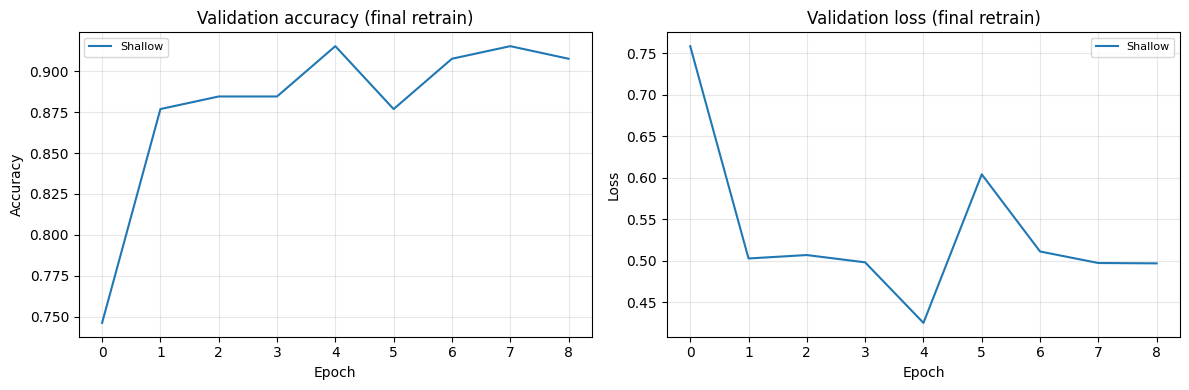

In [33]:
# Overlay validation curves for all variants
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for entry in variant_results:
    h = entry.get('history', {})
    if 'val_accuracy' in h:
        plt.plot(h['val_accuracy'], label=entry['name'])
plt.title('Validation accuracy (final retrain)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(fontsize=8); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for entry in variant_results:
    h = entry.get('history', {})
    if 'val_loss' in h:
        plt.plot(h['val_loss'], label=entry['name'])
plt.title('Validation loss (final retrain)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(fontsize=8); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'training_curves.png', dpi=140, bbox_inches='tight')
plt.show()


## 11. Hold-out test evaluation


In [34]:
# Hold-out evaluation per variant
for entry in variant_results:
    test_loss_v, test_accuracy_v = entry['model'].evaluate(
        entry['X_test_final'], y_test, verbose=0
    )
    y_pred_v = np.argmax(entry['model'].predict(entry['X_test_final'], verbose=0), axis=1)
    rep_v = classification_report(
        y_test, y_pred_v, target_names=le.classes_, output_dict=True, zero_division=0
    )
    entry.update({
        'test_loss': float(test_loss_v),
        'test_accuracy': float(test_accuracy_v),
        'y_pred': y_pred_v,
        'classification_report': rep_v,
    })
    print(f'{entry["name"]:<12} test_loss={test_loss_v:.4f}  test_acc={test_accuracy_v:.4f}')

print('\nConfusion matrix (last variant):')
print(confusion_matrix(y_test, variant_results[-1]['y_pred']))
print('\nClassification report (last variant):')
print(classification_report(
    y_test, variant_results[-1]['y_pred'], target_names=le.classes_, zero_division=0
))

# Legacy aliases for downstream cells
test_loss     = variant_results[-1]['test_loss']
test_accuracy = variant_results[-1]['test_accuracy']
y_pred        = variant_results[-1]['y_pred']


E0000 00:00:1779749332.764245    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Shallow      test_loss=0.1989  test_acc=0.9306

Confusion matrix (last variant):
[[10  0  0  1  0  1]
 [ 0 11  1  0  0  0]
 [ 0  0 12  0  0  0]
 [ 0  0  0 11  1  0]
 [ 0  0  0  0 11  1]
 [ 0  0  0  0  0 12]]

Classification report (last variant):
                                 precision    recall  f1-score   support

Double_ClosedHand_Flip_OpenHand       1.00      0.83      0.91        12
              Double_FingerTips       1.00      0.92      0.96        12
  Double_Okay_Ring_Middle_Pinky       0.92      1.00      0.96        12
Double_OpenHand_Flip_ClosedHand       0.92      0.92      0.92        12
 Double_OpenHand_LPunch_R_Punch       0.92      0.92      0.92        12
                    Double_Snap       0.86      1.00      0.92        12

                       accuracy                           0.93        72
                      macro avg       0.94      0.93      0.93        72
                   weighted avg       0.94      0.93      0.93        72



## 12. Batch test on TestData/Jestin/TwoHandDynamic

The test folder contains one subfolder per gesture (matching the training class names, sometimes with case differences). We use **the subfolder name** as the ground-truth label — this is far more robust than parsing filenames. Class-name matching is case-insensitive so e.g. `TwoHandDynamic_L_Fist_R_LightBulb` (test) maps to `TwoHandDynamic_L_Fist_R_Lightbulb` (training).


In [ ]:
def preprocess_csv_for_cnn(fpath, sensor_cols, resample_n, apply_butter, cutoff, order, fs, scaler,
                            seq_len, n_chan):
    """Read one CSV → (1, seq_len, n_chan) tensor ready for model.predict."""
    df = pd.read_csv(fpath)
    available = [c for c in sensor_cols if c in df.columns]
    if not available:
        raise ValueError('No matching sensor columns')
    if len(available) != len(sensor_cols):
        # Pad missing columns with zeros so the channel order matches training
        data = np.zeros((len(df), len(sensor_cols)), dtype=np.float32)
        idx_map = {c: i for i, c in enumerate(sensor_cols)}
        for c in available:
            data[:, idx_map[c]] = df[c].values.astype(np.float32)
    else:
        data = df[sensor_cols].values.astype(np.float32)

    if resample_n is not None:
        data = resample_trial(data, resample_n)
    if apply_butter:
        data = apply_butterworth([data], cutoff, order, fs)[0]
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    if scaler is not None:
        # PerTrialStandardScaler is stateless — apply per-trial z-score directly.
        if isinstance(scaler, PerTrialStandardScaler):
            data = _apply_per_trial_zscore(data[np.newaxis, ...])[0]
        else:
            data = scaler.transform(data.reshape(1, -1)).reshape(seq_len, n_chan).astype(np.float32)

    return data.reshape(1, seq_len, n_chan)


def build_test_label_map(class_names):
    """Case-insensitive map from test-folder class name → training class name."""
    m = {}
    for cls in class_names:
        m[cls.lower()] = cls
    return m


def run_batch_test(test_root, model, scaler, le, sensor_cols, class_names,
                   resample_n, apply_butter, cutoff, order, fs, seq_len, n_chan):
    test_root = os.path.expanduser(test_root)
    if not os.path.isdir(test_root):
        raise FileNotFoundError(f'BATCH_TEST_ROOT not found: {test_root!r}')

    label_map = build_test_label_map(class_names)
    sub_dirs = sorted(d for d in os.listdir(test_root)
                      if os.path.isdir(os.path.join(test_root, d)))
    if not sub_dirs:
        print(f'No subfolders found in {test_root}')
        return None

    correct, total, unrecognised = 0, 0, 0
    per_class = {}
    rows = []
    print(f'Batch testing files from {len(sub_dirs)} subfolders under {test_root}')
    print('-' * 100)

    for sub in sub_dirs:
        true_label = label_map.get(sub.lower())
        sub_path = os.path.join(test_root, sub)
        csv_files = sorted(f for f in glob.glob(os.path.join(sub_path, '*.csv'))
                           if not os.path.basename(f).startswith('_'))
        if true_label is None:
            print(f'  ? subfolder {sub!r} has no matching training class — skipping ({len(csv_files)} files)')
            unrecognised += len(csv_files)
            continue

        per_class.setdefault(true_label, {'correct': 0, 'total': 0})

        for fpath in csv_files:
            fname = os.path.basename(fpath)
            try:
                x = preprocess_csv_for_cnn(
                    fpath, sensor_cols,
                    resample_n, apply_butter, cutoff, order, fs,
                    scaler, seq_len, n_chan,
                )
                probs = model.predict(x, verbose=0)[0]
                pred_idx = int(np.argmax(probs))
                pred = le.inverse_transform([pred_idx])[0]
                conf = float(probs.max())
                ok = (pred == true_label)
                correct += int(ok); total += 1
                per_class[true_label]['correct'] += int(ok)
                per_class[true_label]['total']   += 1
                rows.append({'file': fname, 'true': true_label, 'pred': pred,
                             'confidence': conf, 'correct': ok})
                tag = '✓' if ok else '✗'
                t_short = true_label.replace('TwoHandDynamic_', '')
                p_short = pred.replace('TwoHandDynamic_', '')
                print(f'  {tag} {fname[:50]:<52}  true={t_short:<28}  pred={p_short:<28}  conf={conf:.3f}')
            except Exception as e:
                print(f'  ERROR {fname}: {e}')

    print('-' * 100)
    if total > 0:
        print(f'Overall batch accuracy: {correct/total:.4f}  ({correct}/{total})')
    if unrecognised:
        print(f'Files in unmatched subfolders: {unrecognised}')

    print('\nPer-class accuracy:')
    for cls, d in sorted(per_class.items()):
        if d['total']:
            print(f'  {cls:<55} {d["correct"]/d["total"]:.4f}  ({d["correct"]}/{d["total"]})')

    return pd.DataFrame(rows), correct, total




In [ ]:
# Batch test per variant (reuses run_batch_test defined above).
# For 2-D variants, wrap the model with a thin Keras Lambda that accepts
# (1, T, C) input and applies reshape_to_grid before the real model.

def _wrap_2d_for_batch_test(inner_model, grid_index):
    """
    
    Return a Keras model that accepts (B, T, C) and predicts via inner_model on (B, T, R, M).
    
    """
    
    grid_index_tf = tf.constant(grid_index, dtype=tf.int32)  # shape (R, M)
    mask = tf.cast(grid_index_tf >= 0, tf.float32)              # (R, M)
    safe_idx = tf.maximum(grid_index_tf, 0)                     # (R, M), 0 wherever empty
    def _reshape(x):
        # x: (B, T, C)  ->  gather channels into (B, T, R, M), zero out empty cells
        gathered = tf.gather(x, safe_idx, axis=-1)              # (B, T, R, M)
        return gathered * mask                                  # zero-fill empties
    inp = Input(shape=inner_model.input_shape[1:-1] + (len(SENSOR_COLS),))
    # Note: inner_model.input_shape is (None, T, R, M). We need an outer input of (None, T, C).
    # Rebuild explicitly:
    T_dim = inner_model.input_shape[1]
    outer_in = Input(shape=(T_dim, len(SENSOR_COLS)))
    reshaped = Lambda(_reshape, output_shape=inner_model.input_shape[1:])(outer_in)
    return Model(inputs=outer_in, outputs=inner_model(reshaped))

for entry in variant_results:
    print(f'\n── Batch test: {entry["name"]} ──')
    if entry.get('is_2d', entry['name'].startswith('CNN2D_')):
        # Wrap so run_batch_test (which feeds (1, T, C)) still works
        wrapped = _wrap_2d_for_batch_test(entry['model'], GRID_INDEX)
        _model_for_batch = wrapped
    else:
        _model_for_batch = entry['model']
    res = run_batch_test(
        BATCH_TEST_ROOT, _model_for_batch, entry['scaler'], le,
        SENSOR_COLS, class_names,
        RESAMPLE_TO_N_STEPS, APPLY_BUTTERWORTH, BUTTERWORTH_CUTOFF_HZ, BUTTERWORTH_ORDER,
        SAMPLING_RATE_HZ, sequence_length, n_channels,
    )
    if res is not None:
        df_v, c_v, t_v = res
        entry['batch_df'] = df_v
        entry['batch_correct'] = int(c_v)
        entry['batch_total'] = int(t_v)
        entry['batch_accuracy'] = float(c_v / t_v) if t_v else None
    else:
        entry['batch_df'] = None
        entry['batch_correct'] = 0
        entry['batch_total'] = 0
        entry['batch_accuracy'] = None

print('\n=== Summary across variants ===')
print(f'{"Variant":<12}  {"params":>10}  {"CV":>16}  {"hold-out":>10}  {"batch":>10}')
for e in variant_results:
    cv = f'{e["cv_mean"]:.3f}±{e["cv_std"]:.3f}' if e["cv_mean"] is not None else '—'
    bt = f'{e["batch_accuracy"]:.3f}' if e["batch_accuracy"] is not None else '—'
    print(f'{e["name"]:<12}  {e["n_params"]:>10,}  {cv:>16}  {e["test_accuracy"]:>10.3f}  {bt:>10}')

# Legacy aliases
batch_df = variant_results[-1].get('batch_df')
batch_correct = variant_results[-1].get('batch_correct', 0)
batch_total = variant_results[-1].get('batch_total', 0)
batch_test_accuracy = variant_results[-1].get('batch_accuracy')



── Batch test: Shallow ──
Batch testing files from 6 subfolders under /home/jestin/ThesisRepo2/NewTestData/8_Jestin/NewNewDynamic
----------------------------------------------------------------------------------------------------
  ✓ glove_data_L_NewNewDynamic_Double_ClosedHand_Flip_    true=Double_ClosedHand_Flip_OpenHand  pred=Double_ClosedHand_Flip_OpenHand  conf=0.770
  ✓ glove_data_L_NewNewDynamic_Double_ClosedHand_Flip_    true=Double_ClosedHand_Flip_OpenHand  pred=Double_ClosedHand_Flip_OpenHand  conf=0.957
  ✓ glove_data_L_NewNewDynamic_Double_ClosedHand_Flip_    true=Double_ClosedHand_Flip_OpenHand  pred=Double_ClosedHand_Flip_OpenHand  conf=0.729
  ✓ glove_data_L_NewNewDynamic_Double_ClosedHand_Flip_    true=Double_ClosedHand_Flip_OpenHand  pred=Double_ClosedHand_Flip_OpenHand  conf=1.000
  ✓ glove_data_L_NewNewDynamic_Double_ClosedHand_Flip_    true=Double_ClosedHand_Flip_OpenHand  pred=Double_ClosedHand_Flip_OpenHand  conf=0.988
  ✗ glove_data_L_NewNewDynamic_Double_Close

E0000 00:00:1779749337.798343    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  ✓ glove_data_L_NewNewDynamic_Double_Okay_Ring_Middle    true=Double_Okay_Ring_Middle_Pinky  pred=Double_Okay_Ring_Middle_Pinky  conf=0.986
  ✓ glove_data_L_NewNewDynamic_Double_Okay_Ring_Middle    true=Double_Okay_Ring_Middle_Pinky  pred=Double_Okay_Ring_Middle_Pinky  conf=1.000
  ✓ glove_data_L_NewNewDynamic_Double_Okay_Ring_Middle    true=Double_Okay_Ring_Middle_Pinky  pred=Double_Okay_Ring_Middle_Pinky  conf=1.000
  ✓ glove_data_L_NewNewDynamic_Double_Okay_Ring_Middle    true=Double_Okay_Ring_Middle_Pinky  pred=Double_Okay_Ring_Middle_Pinky  conf=1.000
  ✓ glove_data_L_NewNewDynamic_Double_OpenHand_Flip_Cl    true=Double_OpenHand_Flip_ClosedHand  pred=Double_OpenHand_Flip_ClosedHand  conf=1.000
  ✓ glove_data_L_NewNewDynamic_Double_OpenHand_Flip_Cl    true=Double_OpenHand_Flip_ClosedHand  pred=Double_OpenHand_Flip_ClosedHand  conf=1.000
  ✓ glove_data_L_NewNewDynamic_Double_OpenHand_Flip_Cl    true=Double_OpenHand_Flip_ClosedHand  pred=Double_OpenHand_Flip_ClosedHand  conf=1.000
 

E0000 00:00:1779749342.850955    7675 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


## 13. Export PDF report (parameters, paths, results)

Builds a compact PDF summarising the configuration, data locations, CV folds, hold-out and
batch-test results, and the saved model path. Uses only `reportlab` so it works in any env.


In [38]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
)
from reportlab.lib.enums import TA_LEFT


def _fmt(v, nd=4):
    if v is None:
        return '—'
    if isinstance(v, float):
        return f'{v:.{nd}f}'
    return str(v)


_VAL_STYLE = ParagraphStyle('KVValue', fontName='Helvetica', fontSize=7.5, leading=9.5,
                            textColor=colors.HexColor('#222222'))
_KEY_STYLE = ParagraphStyle('KVKey',   fontName='Helvetica-Bold', fontSize=7.5, leading=9.5,
                            textColor=colors.HexColor('#333333'))


def _wrap(text, style=_VAL_STYLE):
    if isinstance(text, Paragraph):
        return text
    s = str(text).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    return Paragraph(s, style)


def _kv_table(rows, col_widths=(50*mm, 135*mm)):
    wrapped = [[_wrap(r[0], _KEY_STYLE), _wrap(r[1], _VAL_STYLE)] for r in rows]
    tbl = Table(wrapped, colWidths=col_widths, hAlign='LEFT')
    tbl.setStyle(TableStyle([
        ('VALIGN',       (0, 0), (-1, -1), 'TOP'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
        ('TOPPADDING',   (0, 0), (-1, -1), 1),
        ('LINEBELOW',    (0, 0), (-1, -2), 0.25, colors.HexColor('#dddddd')),
    ]))
    return tbl


_CELL_STYLE = ParagraphStyle('CellVal', fontName='Helvetica', fontSize=7,
                             leading=8.5, alignment=1,  # 1 = TA_CENTER
                             textColor=colors.HexColor('#222222'))
_CELL_BOLD  = ParagraphStyle('CellHdr', fontName='Helvetica-Bold', fontSize=7,
                             leading=8.5, alignment=1,
                             textColor=colors.HexColor('#222222'))


def _grid_table(rows, col_widths, font_size=7):
    """Header-row styled grid table (used for the SENSOR_GRID summary)."""
    tbl = Table(rows, colWidths=col_widths, hAlign='LEFT')
    tbl.setStyle(TableStyle([
        ('FONT',         (0, 0), (-1, -1), 'Helvetica',     font_size),
        ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', font_size),
        ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
        ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
        ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
        ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1.5),
        ('TOPPADDING',   (0, 0), (-1, -1), 1.5),
    ]))
    return tbl


def _section(title, styles):
    return Paragraph(f'<b>{title}</b>', styles['Section'])


def _build_confusion_matrix_chart(y_true, y_pred, class_names, out_path,
                                  title='Confusion matrix', normalize=False):
    """Render a labelled confusion-matrix heatmap to PNG.

    y_true / y_pred can be either integer-encoded indices or string labels —
    `class_names` defines the row/column ordering either way.
    """
    import numpy as _np
    import matplotlib.pyplot as _plt
    from sklearn.metrics import confusion_matrix as _cm
    if len(y_true) == 0 or len(y_pred) == 0:
        return False
    # confusion_matrix infers from `labels=` so we get a stable ordering
    labels_arg = list(class_names)
    cm = _cm(y_true, y_pred, labels=labels_arg)
    if normalize:
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_disp = _np.divide(cm, row_sum, out=_np.zeros_like(cm, dtype=float),
                             where=row_sum > 0)
        fmt_fn = lambda v: f'{v:.2f}' if v > 0 else ''
    else:
        cm_disp = cm.astype(float)
        fmt_fn = lambda v: str(int(v)) if v > 0 else ''
    n = len(labels_arg)
    # Auto-size for legibility: ~0.55 inch per class, clamped
    side = max(4.0, min(11.0, 0.55 * n + 2.0))
    fig, ax = _plt.subplots(figsize=(side, side * 0.92), dpi=150)
    im = ax.imshow(cm_disp, interpolation='nearest', cmap='Blues',
                   vmin=0, vmax=(1.0 if normalize else cm_disp.max() if cm_disp.max() > 0 else 1))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    short = [c.replace('TwoHandDynamic_', '') for c in labels_arg]
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short, fontsize=7)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=9)
    # Annotate cells (skip annotation when grid is huge to avoid clutter)
    if n <= 14:
        thresh = (cm_disp.max() / 2.0) if cm_disp.max() > 0 else 0
        for i in range(n):
            for j in range(n):
                v = cm_disp[i, j]
                txt = fmt_fn(v)
                if not txt:
                    continue
                ax.text(j, i, txt, ha='center', va='center', fontsize=6.5,
                        color=('white' if v > thresh else '#222'))
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    _plt.close(fig)
    return True


def _build_comparison_chart(variant_results, out_path, batch_subject):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    labels    = [r['name'] for r in variant_results]
    cv_means  = [r['cv_mean'] if r['cv_mean'] is not None else 0 for r in variant_results]
    cv_stds   = [r['cv_std']  if r['cv_std']  is not None else 0 for r in variant_results]
    test_accs = [r['test_accuracy'] for r in variant_results]
    batch_acc = [r['batch_accuracy'] if r['batch_accuracy'] is not None else 0 for r in variant_results]
    x = np.arange(len(labels)); w = 0.27
    ax.bar(x - w, cv_means,  w, yerr=cv_stds, capsize=3, label=f'CV mean (k={CV_FOLDS})', color='#4c78a8')
    ax.bar(x,     test_accs, w, label='Hold-out', color='#f58518')
    ax.bar(x + w, batch_acc, w, label=f'Batch ({batch_subject})', color='#54a24b')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Accuracy')
    ax.set_title('1D CNN architecture variants — accuracy comparison')
    ax.legend(loc='lower right', fontsize=8); ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(test_accs):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=7)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140); plt.close()


def export_variants_report_pdf(out_path):
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name='Section',    parent=styles['Heading2'],
                              fontSize=11, spaceBefore=6, spaceAfter=2,
                              textColor=colors.HexColor('#1a3a6c')))
    styles.add(ParagraphStyle(name='SubSection', parent=styles['Heading3'],
                              fontSize=9.5, spaceBefore=4, spaceAfter=1,
                              textColor=colors.HexColor('#2a4a7c')))
    styles.add(ParagraphStyle(name='Small',      parent=styles['BodyText'],
                              fontSize=8, leading=10))
    styles['Title'].fontSize = 15
    styles['Title'].spaceAfter = 4
    styles['Title'].alignment = TA_LEFT

    doc = SimpleDocTemplate(
        str(out_path), pagesize=A4,
        leftMargin=12*mm, rightMargin=12*mm,
        topMargin=10*mm, bottomMargin=10*mm,
        title='1D CNN Variant Comparison',
    )
    story = []
    batch_subject = os.path.basename(os.path.dirname(str(BATCH_TEST_ROOT).rstrip('/'))) or 'batch'

    # Header
    story.append(Paragraph('1D CNN — Architecture Variant Comparison', styles['Title']))
    story.append(Paragraph(f"Generated {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", styles['Small']))
    story.append(Spacer(1, 4))

    # ── Helper to read a config var safely (returns sentinel if missing) ─────
    _MISSING = object()
    def _g(name, default=_MISSING):
        return globals().get(name, default if default is not _MISSING else '<not set>')

    def _fmt_param(v):
        '''Format a single config parameter for the report (avoids clobbering
        the outer `_fmt(value, nd)` used by the comparison summary).'''
        if v is None: return 'None'
        if isinstance(v, bool): return str(v)
        if isinstance(v, (int, float)): return repr(v)
        if isinstance(v, str): return v if v else "''"
        if isinstance(v, (tuple, list)): return repr(v)
        return str(v)

    def _sub_table(rows):
        '''Compact two-column kv subtable for grouped config sections.'''
        wrapped = [[_wrap(r[0], _KEY_STYLE), _wrap(_fmt_param(r[1]), _VAL_STYLE)] for r in rows]
        tbl = Table(wrapped, colWidths=(60*mm, 125*mm), hAlign='LEFT')
        tbl.setStyle(TableStyle([
            ('VALIGN',       (0, 0), (-1, -1), 'TOP'),
            ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
            ('TOPPADDING',   (0, 0), (-1, -1), 1),
            ('LINEBELOW',    (0, 0), (-1, -2), 0.25, colors.HexColor('#dddddd')),
        ]))
        return tbl

    def _subsection(title):
        story.append(Spacer(1, 3))
        story.append(Paragraph(f'<b>{title}</b>', styles['SubSection']))

    # ─────────────────────────────────────────────────────────────────────────
    # Full configuration dump — every parameter from the config cell, grouped.
    # Reading these tables and copying the values back into the notebook is
    # sufficient to reproduce the run.
    # ─────────────────────────────────────────────────────────────────────────
    story.append(_section('Configuration (full)', styles))
    story.append(Paragraph(
        'Every parameter from the configuration cell is reproduced verbatim below. '
        'Copy the values back into the notebook config cell to regenerate this run. '
        'Derived counts (trials / channels / classes) are shown in italics in the '
        'Derived quantities section.',
        styles['Small']))

    # 1. Data locations + label filter
    _subsection('Data locations &amp; class filter')
    _dl_rows = []
    _ap = _g('ACTIVE_DATA_PATHS', []) or []
    if _ap:
        for i, p in enumerate(_ap):
            _dl_rows.append([f'DATA_PATHS[{i}]', p])
    else:
        _dl_rows.append(['DATA_PATHS', '(empty)'])
    _dl_rows += [
        ['DATA_ROOT (legacy)',  _g('DATA_ROOT')],
        ['BATCH_TEST_ROOT',     _g('BATCH_TEST_ROOT')],
        ['TEST_USER',           _g('TEST_USER')],
        ['INCLUDE_LABELS',      _g('INCLUDE_LABELS')],
        ['ReportPostfix',       _g('ReportPostfix', '')],
    ]
    story.append(_sub_table(_dl_rows))

    # 2. Sensor selection (mode + grid data is rendered as its own table below)
    _subsection('Sensor selection')
    _sensors_obj = _g('SENSORS')
    _grid_mode = (_sensors_obj is not None)
    _mode_str = 'SENSOR_GRID dict (fine-grained per-sensor)' if _grid_mode else 'Legacy coarse toggles (SENSORS=None)'
    _ss_rows = [
        ['Selection mode',     _mode_str],
        ['USE_LEFT_HAND',      _g('USE_LEFT_HAND')],
        ['USE_RIGHT_HAND',     _g('USE_RIGHT_HAND')],
        ['INCLUDE_SEGMENTS',   _g('INCLUDE_SEGMENTS')],
    ]
    if _sensors_obj:
        _enabled_ids  = sorted(k for k, v in _sensors_obj.items() if v is True)
        _disabled_ids = sorted(k for k, v in _sensors_obj.items() if v is False)
        _ss_rows += [
            ['SENSORS enabled  (n)',  f'{len(_enabled_ids)}'],
            ['SENSORS disabled (n)',  f'{len(_disabled_ids)}'],
        ]
    story.append(_sub_table(_ss_rows))

    # 2b. SENSOR_GRID rendered as the visual grid (kept as before)
    try:
        _grid_data = SENSOR_GRID
    except NameError:
        _grid_data = None
    if _grid_data:
        story.append(Spacer(1, 3))
        story.append(Paragraph(
            '<b>SENSOR_GRID (✓ enabled, ✗ disabled, — not present)</b>',
            styles['Small']))
        sg_header = [
            _wrap('Hand / Segment', _CELL_BOLD),
            _wrap('IMU_mid',  _CELL_BOLD),
            _wrap('IMU_prox', _CELL_BOLD),
            _wrap('Flex_MCP', _CELL_BOLD),
            _wrap('Flex_PIP', _CELL_BOLD),
        ]
        sg_rows = [sg_header]
        def _mark(v):
            if v == '.':   return '—'
            if v is True:  return '✓'
            if v is False: return '✗'
            return str(v)
        _n_enabled = 0; _n_disabled = 0
        for _hand, _segs in _grid_data.items():
            for _seg, _cells in _segs.items():
                _row = [_wrap(f'{_hand} {_seg}', _CELL_STYLE)]
                for _v in _cells:
                    _row.append(_wrap(_mark(_v), _CELL_STYLE))
                    if _v is True:  _n_enabled  += 1
                    if _v is False: _n_disabled += 1
                sg_rows.append(_row)
        story.append(_grid_table(sg_rows, col_widths=(52*mm, 28*mm, 28*mm, 28*mm, 28*mm), font_size=7.5))

    # 3. IMU channel modalities
    _subsection('IMU channel modalities')
    story.append(_sub_table([
        ['USE_YPR',   _g('USE_YPR')],
        ['USE_QUAT',  _g('USE_QUAT')],
        ['USE_ACCEL', _g('USE_ACCEL')],
        ['USE_FLEX',  _g('USE_FLEX')],
    ]))

    # 4. Preprocessing
    _subsection('Preprocessing')
    story.append(_sub_table([
        ['RESAMPLE_TO_N_STEPS',   _g('RESAMPLE_TO_N_STEPS')],
        ['APPLY_BUTTERWORTH',     _g('APPLY_BUTTERWORTH')],
        ['BUTTERWORTH_CUTOFF_HZ', _g('BUTTERWORTH_CUTOFF_HZ')],
        ['BUTTERWORTH_ORDER',     _g('BUTTERWORTH_ORDER')],
        ['SAMPLING_RATE_HZ',      _g('SAMPLING_RATE_HZ')],
        ['NORMALISATION',         _g('NORMALISATION')],
    ]))

    # 5. Train / test split
    _subsection('Train / test split')
    story.append(_sub_table([
        ['TEST_SIZE',       _g('TEST_SIZE')],
        ['RANDOM_STATE',    _g('RANDOM_STATE')],
        ['STRATIFY_SPLIT',  _g('STRATIFY_SPLIT')],
    ]))

    # 6. Cross-validation
    _subsection('Cross-validation')
    story.append(_sub_table([
        ['RUN_CROSS_VALIDATION', _g('RUN_CROSS_VALIDATION')],
        ['CV_FOLDS',             _g('CV_FOLDS')],
        ['CV_SHUFFLE',           _g('CV_SHUFFLE')],
    ]))

    # 7. Augmentation — master switches, then per-transform table
    _subsection('Augmentation (master switches)')
    story.append(_sub_table([
        ['AUGMENT_TRAINING_DATA',          _g('AUGMENT_TRAINING_DATA')],
        ['AUGMENTATION_COPIES_PER_SAMPLE', _g('AUGMENTATION_COPIES_PER_SAMPLE')],
        ['AUGMENTATION_RANDOM_SEED',       _g('AUGMENTATION_RANDOM_SEED')],
    ]))
    _aug_cfg = _g('AUGMENT_CONFIG', None)
    if isinstance(_aug_cfg, dict) and _aug_cfg:
        story.append(Spacer(1, 2))
        story.append(Paragraph('<b>AUGMENT_CONFIG (per transform)</b>', styles['Small']))
        _aug_header = [
            _wrap('Transform',  _CELL_BOLD),
            _wrap('Enabled',    _CELL_BOLD),
            _wrap('apply_prob', _CELL_BOLD),
            _wrap('Other params', _CELL_BOLD),
        ]
        _aug_rows = [_aug_header]
        for _name, _params in _aug_cfg.items():
            _en = _params.get('enabled', False)
            _ap_val = _params.get('apply_prob', '—')
            _other = {k: v for k, v in _params.items() if k not in ('enabled', 'apply_prob')}
            _other_str = ', '.join(f'{k}={_fmt_param(v)}' for k, v in _other.items()) if _other else '—'
            _aug_rows.append([
                _wrap(_name, _CELL_STYLE),
                _wrap('✓' if _en else '✗', _CELL_STYLE),
                _wrap(_fmt_param(_ap_val), _CELL_STYLE),
                _wrap(_other_str, _CELL_STYLE),
            ])
        story.append(_grid_table(_aug_rows,
                                 col_widths=(36*mm, 18*mm, 22*mm, 109*mm),
                                 font_size=7.5))

    # 8. Training hyperparameters
    _subsection('Training hyperparameters')
    story.append(_sub_table([
        ['TRAIN_EPOCHS',           _g('TRAIN_EPOCHS')],
        ['TRAIN_BATCH_SIZE',       _g('TRAIN_BATCH_SIZE')],
        ['TRAIN_VALIDATION_SPLIT', _g('TRAIN_VALIDATION_SPLIT')],
        ['TRAIN_VERBOSE',          _g('TRAIN_VERBOSE')],
    ]))

    # 9. Early stopping
    _subsection('Early stopping')
    story.append(_sub_table([
        ['EARLY_STOPPING_ENABLED',      _g('EARLY_STOPPING_ENABLED')],
        ['EARLY_STOPPING_MONITOR',      _g('EARLY_STOPPING_MONITOR')],
        ['EARLY_STOPPING_PATIENCE',     _g('EARLY_STOPPING_PATIENCE')],
        ['EARLY_STOPPING_MIN_DELTA',    _g('EARLY_STOPPING_MIN_DELTA')],
        ['EARLY_STOPPING_RESTORE_BEST', _g('EARLY_STOPPING_RESTORE_BEST')],
        ['EARLY_STOPPING_VERBOSE',      _g('EARLY_STOPPING_VERBOSE')],
    ]))

    # 10. Output paths
    _subsection('Output paths')
    story.append(_sub_table([
        ['MODEL_OUTPUT_DIR',    str(_g('MODEL_OUTPUT_DIR'))],
        ['EXPERIMENT_LOG_PATH', str(_g('EXPERIMENT_LOG_PATH'))],
    ]))

    # 11. Variants in this run
    _subsection('Variants in this run')
    _variants_cfg = _g('VARIANTS', [])
    if _variants_cfg:
        _v_header = [_wrap('Name', _CELL_BOLD),
                     _wrap('Builder', _CELL_BOLD),
                     _wrap('Description', _CELL_BOLD)]
        _v_rows = [_v_header]
        for _vt in _variants_cfg:
            try:
                _vname, _vdesc, _vbuilder = _vt
            except Exception:
                _vname, _vdesc, _vbuilder = (str(_vt), '', None)
            _bname = getattr(_vbuilder, '__name__', str(_vbuilder))
            _v_rows.append([
                _wrap(_vname, _CELL_STYLE),
                _wrap(_bname, _CELL_STYLE),
                _wrap(_vdesc, _CELL_STYLE),
            ])
        story.append(_grid_table(_v_rows,
                                 col_widths=(28*mm, 38*mm, 119*mm),
                                 font_size=7))

    # 12. Derived quantities (computed at run time, NOT user-set)
    _subsection('Derived quantities (read-only — computed from data)')
    _dq_rows = []
    try:
        _dq_rows.append(['Total trials (X.shape[0])', X.shape[0]])
        _dq_rows.append(['Train pool size',           X_train_pool.shape[0]])
        _dq_rows.append(['Hold-out size',             X_test.shape[0]])
    except Exception:
        pass
    try:
        _dq_rows.append(['Sequence length',           sequence_length])
        _dq_rows.append(['Sensor channels',           n_channels])
    except Exception:
        pass
    try:
        _dq_rows.append(['Number of classes',         n_classes])
        _dq_rows.append(['Class names',               ', '.join(le.classes_)])
    except Exception:
        pass
    try:
        _dq_rows.append(['len(SENSOR_COLS)',          len(SENSOR_COLS)])
    except Exception:
        pass
    if _dq_rows:
        story.append(_sub_table(_dq_rows))

    story.append(Spacer(1, 4))

    # Comparison summary table
    story.append(_section('Variant comparison (summary)', styles))
    summary_rows = [['Variant', 'Params', f'CV mean (k={CV_FOLDS})', 'CV std',
                     'Hold-out acc', 'Hold-out loss', 'Batch acc', 'Batch n']]
    for r in variant_results:
        summary_rows.append([
            r['name'],
            f"{r['n_params']:,}",
            _fmt(r['cv_mean'], 4),
            _fmt(r['cv_std'], 4),
            _fmt(r['test_accuracy'], 4),
            _fmt(r['test_loss'], 4),
            _fmt(r['batch_accuracy'], 4) if r['batch_accuracy'] is not None else '—',
            f"{r['batch_correct']}/{r['batch_total']}" if r['batch_total'] else '—',
        ])
    best_test = max(variant_results, key=lambda r: r['test_accuracy'])['name']
    best_cv   = max(variant_results, key=lambda r: r['cv_mean'] or 0)['name']
    summary_t = Table(summary_rows, hAlign='LEFT',
                      colWidths=(22*mm, 22*mm, 24*mm, 18*mm, 24*mm, 22*mm, 22*mm, 18*mm))
    style_cmds = [
        ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7.5),
        ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7.5),
        ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
        ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
        ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
        ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
        ('TOPPADDING',   (0, 0), (-1, -1), 1),
    ]
    for i, r in enumerate(variant_results, start=1):
        if r['name'] == best_test:
            style_cmds.append(('BACKGROUND', (0, i), (-1, i), colors.HexColor('#fff7e0')))
    summary_t.setStyle(TableStyle(style_cmds))
    story.append(summary_t)
    story.append(Spacer(1, 3))
    story.append(Paragraph(f'Best on hold-out: <b>{best_test}</b> · Best on CV: <b>{best_cv}</b>', styles['Small']))

    # Comparison chart
    cmp_chart = MODEL_OUTPUT_DIR / 'variants_comparison.png'
    _build_comparison_chart(variant_results, cmp_chart, batch_subject)
    img_w = 175*mm
    if cmp_chart.exists():
        story.append(Spacer(1, 4))
        story.append(Image(str(cmp_chart), width=img_w, height=img_w*0.5))

    # Training curves (already saved by curves cell)
    curves_path = MODEL_OUTPUT_DIR / 'training_curves.png'
    story.append(_section('Training curves (final retrain on full training pool)', styles))
    if curves_path.exists():
        story.append(Image(str(curves_path), width=img_w, height=img_w*0.36))

    # Per-variant detail pages
    for r in variant_results:
        story.append(PageBreak())
        story.append(Paragraph(f'Variant: {r["name"]}', styles['Title']))
        story.append(Paragraph(r['description'], styles['Small']))
        story.append(Spacer(1, 4))

        story.append(_kv_table([
            ['Trainable params',         f'{r["n_params"]:,}'],
            ['CV mean ± std',           f'{_fmt(r["cv_mean"])} ± {_fmt(r["cv_std"])}'],
            ['Hold-out test acc / loss', f'{_fmt(r["test_accuracy"])} · {_fmt(r["test_loss"])}'],
            ['Batch-test acc',
             f'{_fmt(r["batch_accuracy"])}  ({r["batch_correct"]}/{r["batch_total"]})'
             if r['batch_total'] else '—'],
        ]))

        if r['cv_fold_results']:
            story.append(Paragraph('<b>Cross-validation folds</b>', styles['SubSection']))
            ftbl = [['Fold', 'Train (post-aug)', 'Val', 'Val acc', 'Best val', 'Final val']]
            for fr in r['cv_fold_results']:
                ftbl.append([fr['fold'], fr['train_after_aug'], fr['val_samples'],
                             _fmt(fr['val_accuracy']),
                             _fmt(fr['best_val_accuracy']),
                             _fmt(fr['final_val_accuracy'])])
            t = Table(ftbl, hAlign='LEFT',
                      colWidths=(12*mm, 30*mm, 16*mm, 22*mm, 22*mm, 22*mm))
            t.setStyle(TableStyle([
                ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7.5),
                ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7.5),
                ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
                ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
                ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
                ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
                ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
                ('TOPPADDING',   (0, 0), (-1, -1), 1),
            ]))
            story.append(t)

        # Per-class hold-out metrics
        story.append(Paragraph('<b>Per-class hold-out metrics</b>', styles['SubSection']))
        rep = r['classification_report']
        _cell = ParagraphStyle('Cell', fontName='Helvetica', fontSize=7, leading=8.5)
        cls_rows = [['Class', 'Precision', 'Recall', 'F1', 'Support']]
        for cls in le.classes_:
            d = rep.get(cls, {})
            cls_rows.append([_wrap(cls, _cell),
                             _fmt(d.get('precision'), 3),
                             _fmt(d.get('recall'), 3),
                             _fmt(d.get('f1-score'), 3),
                             int(d.get('support', 0))])
        for tag in ('macro avg', 'weighted avg'):
            d = rep.get(tag, {})
            cls_rows.append([tag,
                             _fmt(d.get('precision'), 3),
                             _fmt(d.get('recall'), 3),
                             _fmt(d.get('f1-score'), 3),
                             int(d.get('support', 0))])
        ct = Table(cls_rows, hAlign='LEFT', colWidths=(82*mm, 20*mm, 20*mm, 20*mm, 18*mm))
        ct.setStyle(TableStyle([
            ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7),
            ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7),
            ('FONT',         (0, -2), (-1, -1), 'Helvetica-Oblique', 7),
            ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
            ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
            ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
            ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
            ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
            ('TOPPADDING',   (0, 0), (-1, -1), 1),
        ]))
        story.append(ct)

        # Hold-out confusion matrix (counts + row-normalised, side-by-side)
        if r.get('y_pred') is not None and len(r['y_pred']) > 0:
            try:
                _ho_true_lbls = le.inverse_transform(np.asarray(y_test).astype(int))
                _ho_pred_lbls = le.inverse_transform(np.asarray(r['y_pred']).astype(int))
            except Exception:
                # Already string-labelled
                _ho_true_lbls = np.asarray(y_test)
                _ho_pred_lbls = np.asarray(r['y_pred'])
            _safe = ''.join(ch if ch.isalnum() else '_' for ch in r['name'])
            cm_count_path = MODEL_OUTPUT_DIR / f'cm_holdout_{_safe}_counts.png'
            cm_norm_path  = MODEL_OUTPUT_DIR / f'cm_holdout_{_safe}_norm.png'
            ok_c = _build_confusion_matrix_chart(
                _ho_true_lbls, _ho_pred_lbls, list(le.classes_), cm_count_path,
                title=f'{r["name"]} — hold-out confusion matrix (counts)',
                normalize=False,
            )
            ok_n = _build_confusion_matrix_chart(
                _ho_true_lbls, _ho_pred_lbls, list(le.classes_), cm_norm_path,
                title=f'{r["name"]} — hold-out confusion matrix (row-normalised)',
                normalize=True,
            )
            if ok_c or ok_n:
                story.append(Spacer(1, 4))
                story.append(Paragraph('<b>Hold-out confusion matrix</b>', styles['SubSection']))
                _imgs = []
                _half = (doc.width - 6*mm) / 2.0
                if ok_c:
                    _imgs.append(Image(str(cm_count_path), width=_half, height=_half))
                if ok_n:
                    _imgs.append(Image(str(cm_norm_path),  width=_half, height=_half))
                if len(_imgs) == 2:
                    cm_tbl = Table([_imgs], colWidths=(_half, _half), hAlign='LEFT')
                    cm_tbl.setStyle(TableStyle([
                        ('VALIGN', (0,0), (-1,-1), 'TOP'),
                        ('LEFTPADDING',(0,0),(-1,-1),0),
                        ('RIGHTPADDING',(0,0),(-1,-1),0),
                    ]))
                    story.append(cm_tbl)
                else:
                    story.append(_imgs[0])

        # Batch-test per class
        if r.get('batch_df') is not None and len(r['batch_df']) > 0:
            story.append(Paragraph(f'<b>Batch test per class ({batch_subject})</b>', styles['SubSection']))
            bt_rows = [['Class', 'Correct', 'Total', 'Accuracy']]
            for cls, g in r['batch_df'].groupby('true'):
                c = int(g['correct'].sum()); n = int(len(g))
                bt_rows.append([_wrap(cls, _cell), c, n, _fmt(c/n if n else 0.0, 3)])
            bt_rows.append(['Overall', r['batch_correct'], r['batch_total'],
                            _fmt(r['batch_accuracy'], 3) if r['batch_accuracy'] is not None else '—'])
            bt = Table(bt_rows, hAlign='LEFT', colWidths=(102*mm, 20*mm, 20*mm, 22*mm))
            bt.setStyle(TableStyle([
                ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7),
                ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7),
                ('FONT',         (0, -1), (-1, -1), 'Helvetica-Bold', 7),
                ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
                ('BACKGROUND',   (0, -1), (-1, -1), colors.HexColor('#fff7e0')),
                ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
                ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
                ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
                ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
                ('TOPPADDING',   (0, 0), (-1, -1), 1),
            ]))
            story.append(bt)

            # Batch-test confusion matrix
            try:
                _bt_true = r['batch_df']['true'].tolist()
                _bt_pred = r['batch_df']['pred'].tolist()
            except Exception:
                _bt_true, _bt_pred = [], []
            if _bt_true and _bt_pred:
                _safe = ''.join(ch if ch.isalnum() else '_' for ch in r['name'])
                cm_b_count = MODEL_OUTPUT_DIR / f'cm_batch_{_safe}_counts.png'
                cm_b_norm  = MODEL_OUTPUT_DIR / f'cm_batch_{_safe}_norm.png'
                ok_c = _build_confusion_matrix_chart(
                    _bt_true, _bt_pred, list(le.classes_), cm_b_count,
                    title=f'{r["name"]} — batch confusion matrix (counts)',
                    normalize=False,
                )
                ok_n = _build_confusion_matrix_chart(
                    _bt_true, _bt_pred, list(le.classes_), cm_b_norm,
                    title=f'{r["name"]} — batch confusion matrix (row-normalised)',
                    normalize=True,
                )
                if ok_c or ok_n:
                    story.append(Spacer(1, 4))
                    story.append(Paragraph(
                        f'<b>Batch confusion matrix ({batch_subject})</b>',
                        styles['SubSection']))
                    _imgs = []
                    _half = (doc.width - 6*mm) / 2.0
                    if ok_c:
                        _imgs.append(Image(str(cm_b_count), width=_half, height=_half))
                    if ok_n:
                        _imgs.append(Image(str(cm_b_norm),  width=_half, height=_half))
                    if len(_imgs) == 2:
                        bcm_tbl = Table([_imgs], colWidths=(_half, _half), hAlign='LEFT')
                        bcm_tbl.setStyle(TableStyle([
                            ('VALIGN', (0,0), (-1,-1), 'TOP'),
                            ('LEFTPADDING',(0,0),(-1,-1),0),
                            ('RIGHTPADDING',(0,0),(-1,-1),0),
                        ]))
                        story.append(bcm_tbl)
                    else:
                        story.append(_imgs[0])

    doc.build(story)
    print(f'PDF report written to {out_path}')
    return out_path


# Unique filename so re-running never overwrites a previous report
_report_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
_report_filename  = f'variants_report_{_report_timestamp}_{TEST_USER}_zscore_{ReportPostfix}.pdf'
report_pdf_path   = export_variants_report_pdf(MODEL_OUTPUT_DIR / _report_filename)


PDF report written to /home/jestin/ThesisRepo2/NewReports/NewNewDynamic/variants_report_2026-05-26_08-49-03_8_Jestin_zscore_Configuration2_shallow.pdf
